### Flipkart Customer Satisfaction Score Classification Project

# Project Name - Flipkart Classification Project
 

##### **Project Type**    - Classification
##### **Contribution**    - Individual
##### **Name - Aniket Sengupta**

# **Project Summary -**

Flipkart is one of India's largest e-commerce companies, serving millions of customers through a diverse portfolio of products including electronics, fashion, home appliances, and lifestyle goods. As customer expectations continue to rise, delivering high-quality customer support has become essential for maintaining customer satisfaction, improving retention, and strengthening brand loyalty. Customer Satisfaction (CSAT) scores provide valuable feedback on service quality, enabling organizations to measure customer experience and identify opportunities for operational improvement. Predicting customer satisfaction before survey responses are received can help businesses proactively resolve service issues and enhance overall customer experience.

The objective of this project is to develop a machine learning classification model capable of predicting customer satisfaction (CSAT) using historical customer support interaction data. The dataset contains information related to support channels, issue categories, customer remarks, support agents, supervisors, managers, agent shifts, tenure, and issue resolution details. By analyzing these variables, the project aims to identify the operational factors that have the greatest influence on customer satisfaction while building an accurate predictive model that supports data-driven decision-making.

The project begins with extensive Exploratory Data Analysis (EDA) to understand the structure, quality, and characteristics of the dataset. Data quality checks were performed to identify duplicate records, missing values, variable distributions, and relationships among features. A total of twenty visualizations were created, including count plots, box plots, scatter plots, violin plots, heatmaps, pair plots, histograms, pie charts, and line charts. These visualizations helped uncover important business insights regarding customer satisfaction across support channels, issue categories, agent shifts, managers, supervisors, resolution times, and agent tenure. In addition, three hypothesis tests using One-Way ANOVA were conducted to statistically evaluate whether customer support channel, resolution time, and agent shift significantly influence customer satisfaction.

Several preprocessing techniques were applied to prepare the dataset for machine learning. Columns containing excessive missing values or limited predictive value were removed, while a new feature called resolution_time was engineered from issue reporting and response timestamps to capture service efficiency. Missing values were handled appropriately, outliers in the engineered feature were treated using the Interquartile Range (IQR) method, and categorical variables were encoded using Ordinal Encoding. Customer remarks underwent comprehensive Natural Language Processing (NLP), including contraction expansion, lowercase conversion, punctuation and stopword removal, URL cleaning, tokenization, lemmatization, Part-of-Speech (POS) tagging, and TF-IDF vectorization. Mutual Information and correlation analysis were then used to identify the most informative features contributing to customer satisfaction prediction.

To address class imbalance, Synthetic Minority Oversampling Technique (SMOTE) was applied before model training. Two classification algorithms—Logistic Regression and LightGBM Classifier—were developed and evaluated. Both models were further optimized using GridSearchCV with cross-validation to improve their predictive performance. Model evaluation was carried out using Accuracy, Precision, Recall, and F1-Score, followed by a comparative performance analysis. Among the evaluated models, the tuned LightGBM Classifier significantly outperformed Logistic Regression, achieving substantially higher classification performance across all evaluation metrics. The final model was selected based on its superior predictive capability and better generalization to unseen data.

Overall, this project demonstrates how machine learning and data analytics can be leveraged to predict customer satisfaction and generate actionable business insights. The findings enable Flipkart to identify the key drivers of customer experience, optimize customer support operations, reduce issue resolution delays, improve agent performance, and proactively address interactions that may lead to low customer satisfaction. By integrating predictive analytics into customer support processes, the organization can enhance service quality, strengthen customer loyalty, and make more informed operational decisions that contribute to long-term business success.

# **GitHub Link -**

https://github.com/aniket010011/Intern-Projects/blob/main/FlipkartClassificationProject.ipynb

# **Problem Statement**

Customer satisfaction is a key performance indicator for e-commerce companies, as it directly impacts customer loyalty, retention, and business growth. With thousands of customer service interactions occurring daily across multiple support channels, it becomes challenging to manually identify the factors that influence customer satisfaction and predict customer experiences.

The objective of this project is to develop a machine learning classification model that predicts customer satisfaction (CSAT) based on customer service interaction data, including issue details, response time, handling time, product information, and agent performance. The insights obtained from the model can help Flipkart identify the key drivers of customer satisfaction, improve customer support operations, enhance service quality, and make data-driven decisions to deliver a better customer experience.

## Business Objectives

### The following are the business objectives for this project

1. Analyze customer service interactions across different support channels.
2. Identify the key factors influencing customer satisfaction (CSAT).
3. Examine the impact of issue category, response time, and handling time on customer satisfaction.
4. Evaluate the performance of customer service agents, supervisors, and managers.
5. Compare customer satisfaction across product categories and customer locations.
6. Identify service patterns associated with high and low customer satisfaction.
7. Build and evaluate machine learning classification models to predict customer satisfaction.
8. Determine the most important features contributing to customer satisfaction using feature importance analysis.
9. Generate actionable insights to optimize customer support operations and improve service quality.
10. Support data-driven decision-making to enhance customer experience, increase customer loyalty, and improve overall business performance.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
import contractions
import nltk
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, LabelEncoder, label_binarize
from sklearn.datasets import make_blobs
from collections import Counter
from imblearn.over_sampling import SMOTE
import lightgbm as lgbm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, balanced_accuracy_score, roc_auc_score, fbeta_score, precision_score, recall_score
from scipy.stats import f_oneway
import warnings
warnings.filterwarnings('ignore')

C:\ProgramData\anaconda3\lib\site-packages\dask\dataframe\__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


### Dataset Loading

In [2]:
# Load Dataset
df = pd.read_csv("G:/My Drive/Colab Notebooks/Projects/FlipkartProject/Customer_support_data.csv")

### Dataset First View

In [3]:
# Display first 5 rows
df.head(5)

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
df.shape

(85907, 20)

### Dataset Information

In [5]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

#### For Data Cleaning and Preprocessing

In [6]:
# Converting Date and columns to datetime format
date_cols = ["order_date_time", "Issue_reported at", "issue_responded", "Survey_response_Date"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors = "coerce")

#### Duplicate Values Check

In [7]:
# Dataset Duplicate Value Count
# Check for duplicate values
duplicates = df.duplicated(keep=False)

# Count the duplicate values
duplicate_count = duplicates.value_counts()

# Display the number of duplicate values
print(duplicate_count)
print(df.shape)

False    85907
Name: count, dtype: int64
(85907, 20)


#### Missing/Null Values Check

In [8]:
# Missing Value Summary
missing_summary = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df)) * 100
})

missing_summary = missing_summary[missing_summary['Missing Values'] > 0]       # To show only columns containing missing values
missing_summary = missing_summary.sort_values(by='Missing Values', ascending=False)

missing_summary

,Missing Values,Percentage (%)
connected_handling_time,85665,99.718300
Customer_City,68828,80.119199
Product_category,68711,79.983005
Item_price,68701,79.971364
order_date_time,68693,79.962052
Customer Remarks,57165,66.542889
issue_responded,54022,62.884282
Issue_reported at,53933,62.780681
Order_id,18232,21.222950


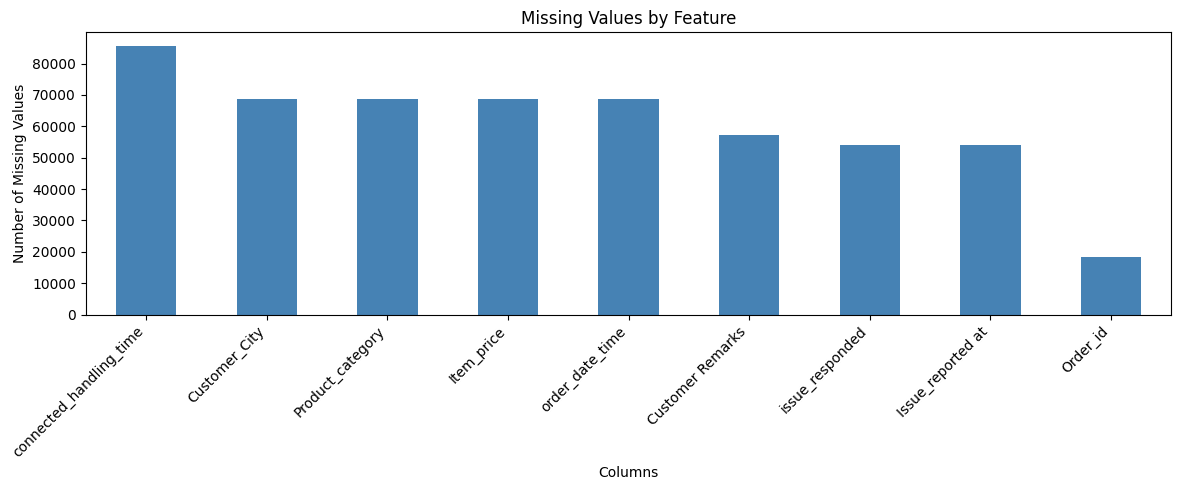

In [9]:
# Visualizing the missing values
plt.figure(figsize=(12,5))

missing_summary['Missing Values'].plot(kind='bar', color='steelblue')

plt.title("Missing Values by Feature")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### What did you know about your dataset?

**The following were known about the dataset:-**

1. Several features contain a substantial number of missing values, with connected_handling_time having the highest number of missing records.
2. Customer-related and order-related attributes such as Customer_city, Product_category, Item_price, order_date_time, and Customer Remarks also exhibit significant missing values, indicating incomplete customer interaction records.
3. Features like issue_reported at, issue_responded, and Order_id contain comparatively fewer missing values and can be handled through appropriate imputation or preprocessing techniques before model development.

## ***2. Understanding Your Variables***

In [10]:
# Dataset Columns
df.columns

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score'],
      dtype='object')

In [11]:
# Dataset Describe
df.describe()

,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Item_price,connected_handling_time,CSAT Score
count,17214,31974,31885,85907,17206.000000,242.000000,85907.000000
mean,2023-07-28 15:49:45.820843520,2023-07-03 05:04:46.427097344,2023-07-03 11:42:31.621138432,2023-08-16 10:18:31.760392192,5660.774846,462.400826,4.242157
min,2022-01-16 13:15:00,2023-01-08 00:00:00,2023-01-08 00:00:00,2023-08-01 00:00:00,0.000000,0.000000,1.000000
25%,2023-07-27 22:49:15,2023-04-08 13:34:00,2023-04-08 13:39:00,2023-08-09 00:00:00,392.000000,293.000000,4.000000
50%,2023-08-04 22:16:30,2023-07-08 16:40:00,2023-07-08 16:52:00,2023-08-16 00:00:00,979.000000,427.000000,5.000000
75%,2023-08-10 07:30:15,2023-10-08 11:19:00,2023-10-08 11:21:00,2023-08-24 00:00:00,2699.750000,592.250000,5.000000
max,2023-12-08 23:36:00,2023-12-08 23:59:00,2023-12-08 23:59:00,2023-08-31 00:00:00,164999.000000,1986.000000,5.000000
std,NaN,NaN,NaN,NaN,12825.728411,246.295037,1.378903


### Variables Description

**The following are the variables with their description:-**

**Column names ---------------------------- Description**

1. Unique id --------------------------- Unique identifier assigned to each customer service interaction.
2. channel_name --------------------------- Customer support channel through which the issue was raised (e.g., Call, Chat, Email).
3. category --------------------------- Main category of the customer issue or request.
4. Sub-category --------------------------- More specific classification of the customer issue.
5. Customer Remarks --------------------------- Feedback or comments provided by the customer regarding the issue.
6. Order_id --------------------------- Unique identifier associated with the customer's order.
7. order_date_time --------------------------- Date and time when the order was placed.
8. Issue_reported at --------------------------- Timestamp when the customer reported the issue.
9. issue_responded --------------------------- Timestamp when the customer support team responded to the issue.
10. Survey_response_Date --------------------------- Date on which the customer submitted the satisfaction survey.
11. Customer_city --------------------------- City from which the customer raised the support request.
12. Product_category --------------------------- Category of the product associated with the customer issue.
13. Item_price --------------------------- Price of the purchased product.
14. connected_handling_time --------------------------- Total time (in minutes) spent handling the customer interaction.
15. Agent_name --------------------------- Name or identifier of the customer service representative handling the issue.
16. Supervisor --------------------------- Name or identifier of the supervisor overseeing the support agent.
17. Manager --------------------------- Name or identifier of the manager responsible for the support team.
18. Tenure Bucket --------------------------- Category representing the support agent's work experience or tenure.
19. Agent Shift --------------------------- Shift during which the customer support agent was working (Morning, Afternoon, Night, etc.).
20. CSAT Score --------------------------- Customer Satisfaction (CSAT) score provided by the customer after the interaction and the target variable for the classification model.

### Check Unique Values for each variable.

In [12]:
# Check Unique Values for each variable.
for x in df.columns:
    print(f"{x} - {df[x].nunique()}")

Unique id - 85907
channel_name - 3
category - 12
Sub-category - 57
Customer Remarks - 18231
Order_id - 67675
order_date_time - 13766
Issue_reported at - 11937
issue_responded - 12032
Survey_response_Date - 31
Customer_City - 1782
Product_category - 9
Item_price - 2789
connected_handling_time - 211
Agent_name - 1371
Supervisor - 40
Manager - 6
Tenure Bucket - 5
Agent Shift - 5
CSAT Score - 5


## 3. ***Data Wrangling***

### Data Wrangling Code

#### Handling Missing/Null Values

In [13]:
# Write your code to make dataset analysis ready.
# checking for the null values in the dataset
df.isnull().sum()

Unique id                      0
channel_name                   0
category                       0
Sub-category                   0
Customer Remarks           57165
Order_id                   18232
order_date_time            68693
Issue_reported at          53933
issue_responded            54022
Survey_response_Date           0
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
dtype: int64

#### Dropping Unnecessary Columns and Columns with high Missing/Null Values

In [14]:
df.drop(['Unique id', 'Order_id', 'order_date_time', 'Survey_response_Date', 'connected_handling_time', 'Customer_City', 'Product_category', 'Item_price'], axis=1, inplace=True)
df.head(5)

,channel_name,category,Sub-category,Customer Remarks,Issue_reported at,issue_responded,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,Outcall,Product Queries,Life Insurance,NaN,2023-01-08 11:13:00,2023-01-08 11:47:00,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,Outcall,Product Queries,Product Specific Information,NaN,2023-01-08 12:52:00,2023-01-08 12:54:00,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,Inbound,Order Related,Installation/demo,NaN,2023-01-08 20:16:00,2023-01-08 20:38:00,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,Inbound,Returns,Reverse Pickup Enquiry,NaN,2023-01-08 20:56:00,2023-01-08 21:16:00,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,Inbound,Cancellation,Not Needed,NaN,2023-01-08 10:30:00,2023-01-08 10:32:00,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [15]:
len(df.columns)

12

In [16]:
df.columns

Index(['channel_name', 'category', 'Sub-category', 'Customer Remarks',
       'Issue_reported at', 'issue_responded', 'Agent_name', 'Supervisor',
       'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score'],
      dtype='object')

#### Feature Engineering

In [17]:
# Converting data in issue reported and issue responded columns into computable form in another column
df['Issue_reported at'] = pd.to_datetime(df['Issue_reported at'], errors="coerce")
df['issue_responded'] = pd.to_datetime(df['issue_responded'], errors="coerce")

# calculate resolution time
df['resolution_time'] = df['issue_responded'] - df['Issue_reported at']
df['resolution_time'] = df['resolution_time'].dt.total_seconds()
df.head(5)

,channel_name,category,Sub-category,Customer Remarks,Issue_reported at,issue_responded,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,resolution_time
0,Outcall,Product Queries,Life Insurance,NaN,2023-01-08 11:13:00,2023-01-08 11:47:00,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5,2040.0
1,Outcall,Product Queries,Product Specific Information,NaN,2023-01-08 12:52:00,2023-01-08 12:54:00,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5,120.0
2,Inbound,Order Related,Installation/demo,NaN,2023-01-08 20:16:00,2023-01-08 20:38:00,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5,1320.0
3,Inbound,Returns,Reverse Pickup Enquiry,NaN,2023-01-08 20:56:00,2023-01-08 21:16:00,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5,1200.0
4,Inbound,Cancellation,Not Needed,NaN,2023-01-08 10:30:00,2023-01-08 10:32:00,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5,120.0


In [18]:
# Removing unnecessary columns after feature engineering
df.drop(['Issue_reported at', 'issue_responded'], axis=1, inplace=True)
print(df.head(5))
print(len(df.columns))

  channel_name         category                  Sub-category  \
0      Outcall  Product Queries                Life Insurance   
1      Outcall  Product Queries  Product Specific Information   
2      Inbound    Order Related             Installation/demo   
3      Inbound          Returns        Reverse Pickup Enquiry   
4      Inbound     Cancellation                    Not Needed   

  Customer Remarks           Agent_name      Supervisor          Manager  \
0              NaN     Richard Buchanan     Mason Gupta  Jennifer Nguyen   
1              NaN        Vicki Collins       Dylan Kim      Michael Lee   
2              NaN         Duane Norman    Jackson Park      William Kim   
3              NaN       Patrick Flores     Olivia Wang       John Smith   
4              NaN  Christopher Sanchez  Austin Johnson      Michael Lee   

     Tenure Bucket Agent Shift  CSAT Score  resolution_time  
0  On Job Training     Morning           5           2040.0  
1              >90     Morni

In [19]:
print(df.columns)
print(len(df.columns))

Index(['channel_name', 'category', 'Sub-category', 'Customer Remarks',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score', 'resolution_time'],
      dtype='object')
11


In [20]:
# Fill missing values with the mean
df['resolution_time'] = df['resolution_time'].fillna(df['resolution_time'].mean())

#### Variables Description after dropping columns with missing values

**The following are the variables with their description:-**

**Column names ---------------------------- Description**

1. channel_name --------------------------- Customer support channel through which the issue was raised (e.g., Call, Chat, Email).
2. category --------------------------- Main category of the customer issue or request.
3. Sub-category --------------------------- More specific classification of the customer issue.
4. Customer Remarks --------------------------- Feedback or comments provided by the customer regarding the reported issue.
5. Agent_name --------------------------- Name or identifier of the customer service representative handling the interaction.
6. Supervisor --------------------------- Name or identifier of the supervisor overseeing the customer support agent.
7. Manager --------------------------- Name or identifier of the manager responsible for the customer support team.
8. Tenure Bucket --------------------------- Category representing the work experience or tenure of the customer support agent.
9. Agent Shift --------------------------- Work shift during which the customer support agent handled the interaction (Morning, Evening, Night, etc.).
10. CSAT Score --------------------------- Customer Satisfaction (CSAT) score assigned by the customer after the interaction and the target variable for the classification model.
11. resolution_time --------------------------- Time taken by the customer support team to resolve the reported issue, calculated as the difference between issue_responded and Issue_reported at (in seconds). This engineered feature captures service efficiency and is expected to be an important predictor of customer satisfaction.

### What all manipulations have you done and insights you found?

**The following data preprocessing and manipulation steps were performed on the dataset:-**

1. Loaded the Flipkart Customer Support dataset into a Pandas DataFrame and examined its dimensions, column names, data types, and summary statistics.
2. Explored the dataset by reviewing the first few records, checking unique values, and understanding the distribution of numerical and categorical variables.
3. Identified duplicate records and removed them to ensure the dataset contained only unique customer support interactions.
4. Analyzed missing values across all variables using summary tables and bar chart visualizations to identify features with a high percentage of missing data.
5. Removed columns containing excessive missing values, including Unique id, Order_id, order_date_time, Survey_response_Date, connected_handling_time, Customer_City, Product_category, and Item_price, to improve data quality and reduce unnecessary complexity.
6. Converted the Issue_reported at and issue_responded columns into datetime format and performed feature engineering by creating a new variable named resolution_time, representing the total time taken to resolve each customer issue in seconds.
7. Removed the original Issue_reported at and issue_responded columns after extracting the required information into the resolution_time feature, thereby reducing redundant variables and improving dataset efficiency.
8. Retained only the most relevant customer interaction, support agent, and engineered features, resulting in a clean dataset containing 11 features that is ready for categorical encoding, model training, and customer satisfaction classification.

## ***4. Data Visualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 - CSAT Score Distribution

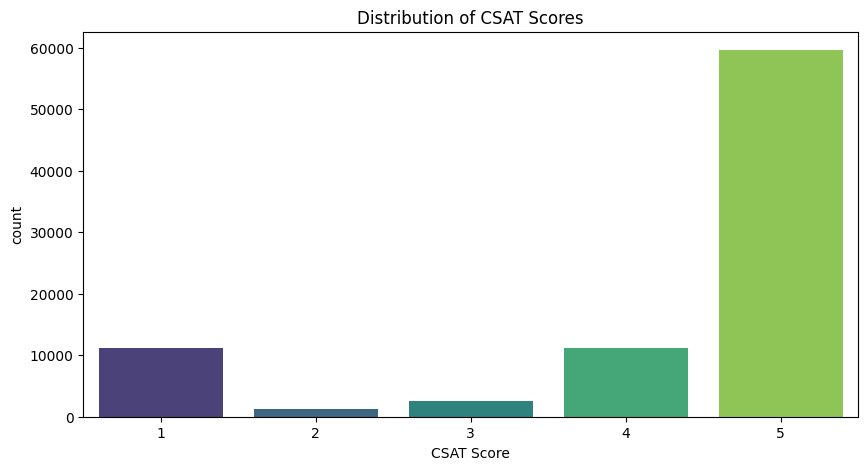

In [21]:
# For CSAT Score distribution
plt.figure(figsize=(10,5))
sns.countplot(x="CSAT Score", data = df, palette = "viridis")
plt.title("Distribution of CSAT Scores")
plt.show()

##### 1. Why did you pick the specific chart?

A count plot was chosen to visualize the distribution of Customer Satisfaction (CSAT) scores because it clearly shows the frequency of each rating category. It helps identify the most common satisfaction levels and reveals any imbalance in the target variable before classification modeling.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above chart:-

1. CSAT Score 5 is the most common rating, indicating that most customers were highly satisfied.
2. CSAT Scores 1 and 4 have moderate frequencies, while Scores 2 and 3 are comparatively less common.
3. The distribution is imbalanced, with a large proportion of responses concentrated at the highest satisfaction level.
4. Overall, the dataset suggests that customer support interactions generally resulted in positive customer experiences.

##### 3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The high number of 5-star CSAT scores indicates strong customer satisfaction, while the smaller number of low ratings helps identify cases where service quality needs improvement. Addressing the factors behind low CSAT scores can enhance customer experience, improve service performance, and increase customer loyalty.

#### Chart - 2 - Customer Satisfaction Across Channels

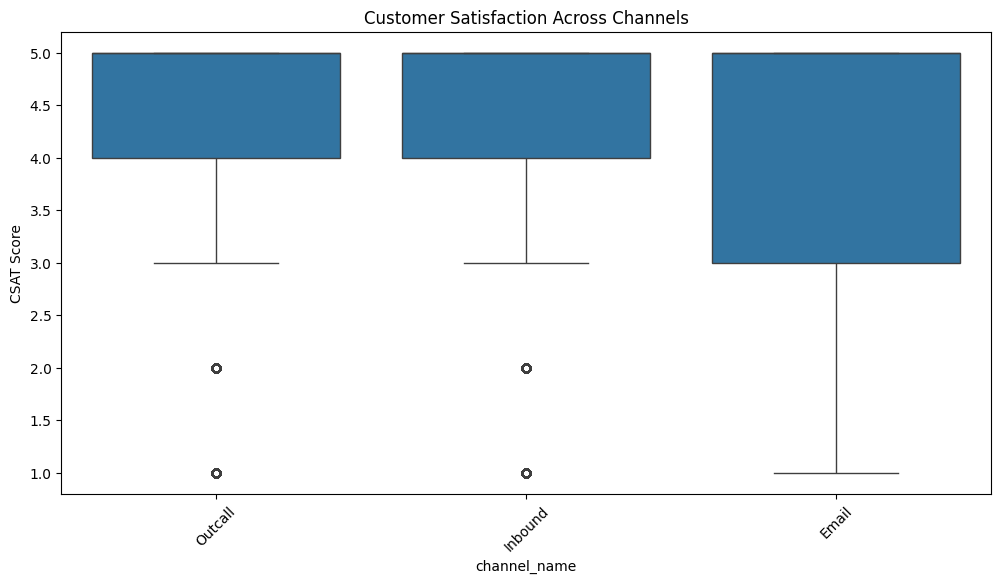

In [22]:
plt.figure(figsize=(12,6))
sns.boxplot(x = "channel_name", y = "CSAT Score", data = df)
plt.xticks(rotation = 45)
plt.title("Customer Satisfaction Across Channels")
plt.show()

##### 1. Why did you pick the specific chart?

A box plot was chosen to compare the distribution of CSAT scores across different customer support channels. It effectively highlights the median, spread, variability, and potential outliers, making it easy to compare customer satisfaction levels between communication channels.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above chart:-

1. All three support channels (Outcall, Inbound, and Email) have a median CSAT score of 5, indicating generally high customer satisfaction.
2. Email shows greater variability in CSAT scores, with ratings ranging from 1 to 5, suggesting more inconsistent customer experiences.
3. Outcall and Inbound channels have more concentrated distributions, with most ratings between 4 and 5.
4. A few low-rating outliers are present across the channels, indicating occasional poor customer service experiences.

##### 3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The consistently high CSAT scores across all channels indicate that Flipkart's customer support performs well overall. However, the wider variation in Email support and the presence of low-score outliers suggest opportunities to improve response quality and consistency. Addressing these issues can increase customer satisfaction, strengthen customer trust, and improve overall service quality.

#### Chart - 3 - Resolution Time vs CSAT Score

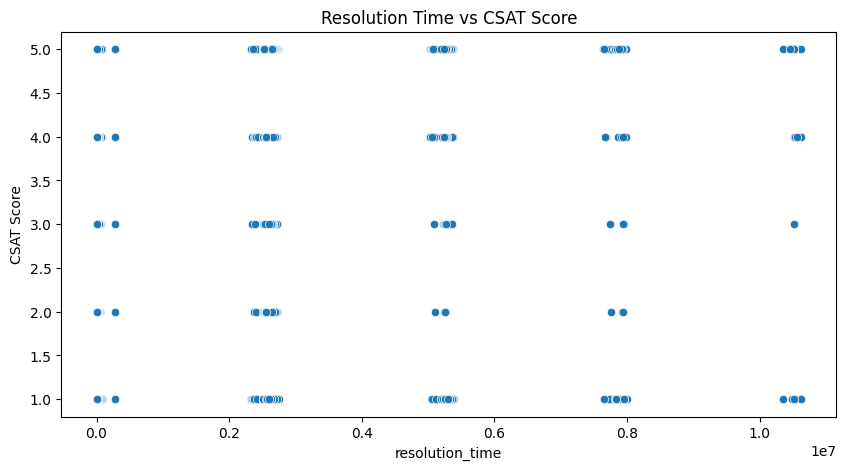

In [23]:
# Comparing Response Time vs CSAT Score
plt.figure(figsize=(10,5))
sns.scatterplot(x = "resolution_time", y = "CSAT Score", data = df)
plt.title("Resolution Time vs CSAT Score")
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot was chosen to examine the relationship between resolution time and CSAT Score. It helps visualize whether longer issue resolution times are associated with lower customer satisfaction and identifies any trends or patterns between the two variables.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above chart:-

1. Customers gave both high and low CSAT scores across different resolution times, indicating that resolution time alone does not determine customer satisfaction.
2. CSAT Score 5 is the most frequently observed rating across almost all resolution time ranges.
3. Lower CSAT scores (1–3) are scattered throughout the plot, suggesting that other factors besides resolution time also influence customer satisfaction.
4. No strong linear relationship is visible between resolution time and CSAT Score.

##### 3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The analysis shows that reducing resolution time alone may not guarantee higher customer satisfaction. Flipkart should also focus on factors such as agent communication, issue resolution quality, and customer experience. Improving these areas alongside efficient resolution can lead to higher CSAT scores, stronger customer loyalty, and better service quality.

#### Chart - 4 - Category Distribution

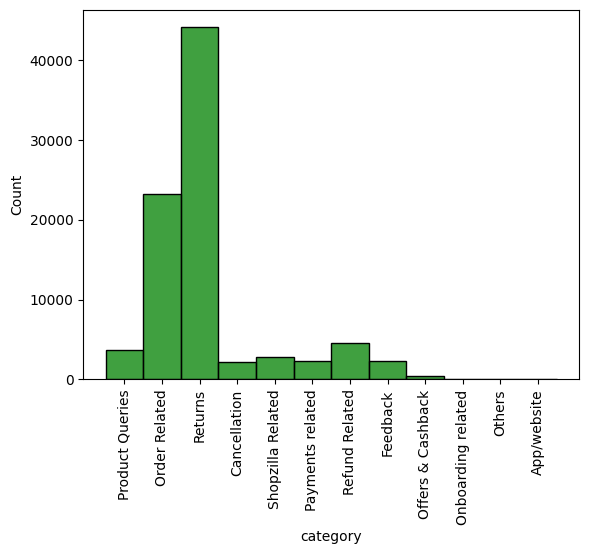

In [24]:
# Category distribution visualization code
sns.histplot(x='category', color='green', data=df)
plt.xticks(rotation=90)
plt.show()

##### 1. Why did you pick the specific chart?

A histogram (histplot) was chosen to visualize the distribution of customer support issue categories. It helps understand how support requests are distributed across different categories and quickly identifies the most frequently occurring issue types.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above chart:-

1. Returns is the most frequent customer support category, indicating it generates the highest number of support requests.
2. Order Related issues are also common, making them another major reason customers contact support.
3. Categories such as Refund Related, Feedback, and Cancellation have comparatively fewer requests than the top two categories.
4. App/Website, Others, and Onboarding Related receive the least number of support requests, suggesting relatively fewer issues in these areas.

##### 3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The histogram highlights that Returns and Order Related issues account for a significant share of customer support requests. By improving return policies, order tracking, and delivery processes, Flipkart can reduce customer complaints, improve customer satisfaction, and enhance overall service efficiency.

#### Chart - 5 - Manager Distribution

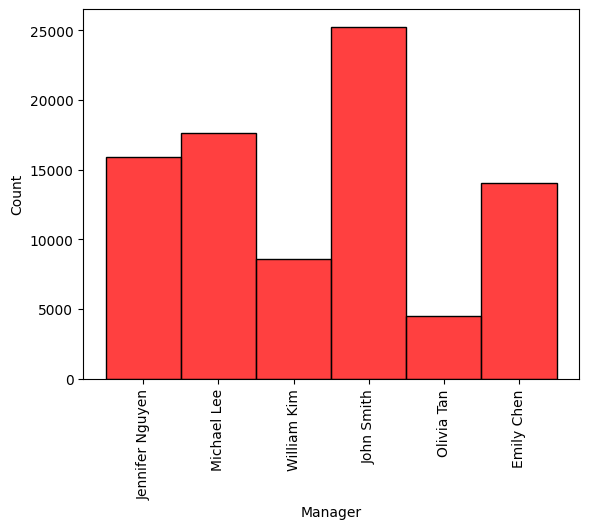

In [25]:
# Manager Distribution visualization code
sns.histplot(x='Manager', color='red', data=df)
plt.xticks(rotation=90)
plt.show()

##### 1. Why did you pick the specific chart?

A histogram (histplot) was chosen to visualize the distribution of customer support cases across different managers. It helps compare the workload handled by each manager and identifies which managers oversee the highest and lowest number of customer interactions.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above chart:-

1. John Smith manages the highest number of customer support cases among all managers.
2. Michael Lee and Jennifer Nguyen also supervise a significant number of customer interactions.
3. Olivia Tan handles the fewest customer support cases, indicating a comparatively lighter workload.
4. The distribution of cases varies across managers, suggesting an uneven allocation of customer support responsibilities.

##### 3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The variation in workloads among managers indicates opportunities to better balance customer support responsibilities. A more even distribution of cases can improve team efficiency, reduce manager workload, enhance service quality, and ultimately contribute to higher customer satisfaction.

#### Chart - 6 - Superviser Distribution

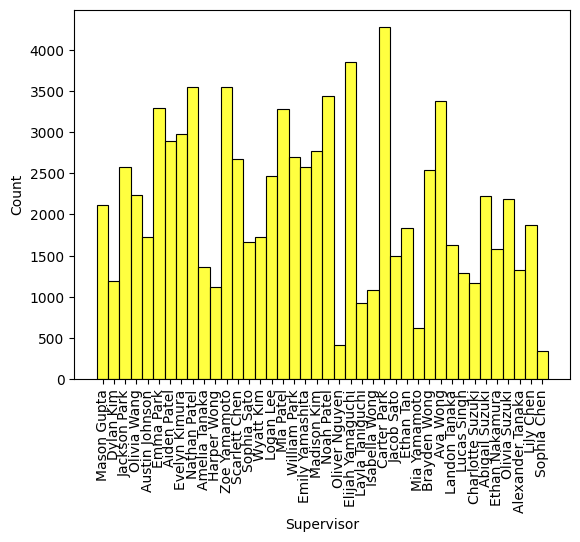

In [26]:
# Superviser Distribution visualization code
sns.histplot(x='Supervisor', color='yellow', data=df)
plt.xticks(rotation=90)
plt.show()

##### 1. Why did you pick the specific chart?

A histogram (histplot) was chosen to visualize the distribution of customer support cases across different supervisors. It helps compare how customer interactions are distributed among supervisors and identifies supervisors handling relatively higher or lower workloads.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above chart:-

1. Customer support cases are distributed across a large number of supervisors, indicating a broad supervisory structure.
2. Some supervisors manage noticeably more customer interactions than others, suggesting differences in workload allocation.
3. Most supervisors handle a moderate number of cases, while only a few supervise very high or very low volumes.
4. The distribution indicates that customer support responsibilities are shared across multiple supervisory teams rather than concentrated under a few individuals.

##### 3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The variation in supervisor workloads can help management identify teams that may be overburdened or underutilized. Balancing workloads more effectively can improve team productivity, ensure consistent service quality, reduce employee fatigue, and ultimately enhance customer satisfaction.

#### Chart - 7 - Resolution Time by CSAT Score

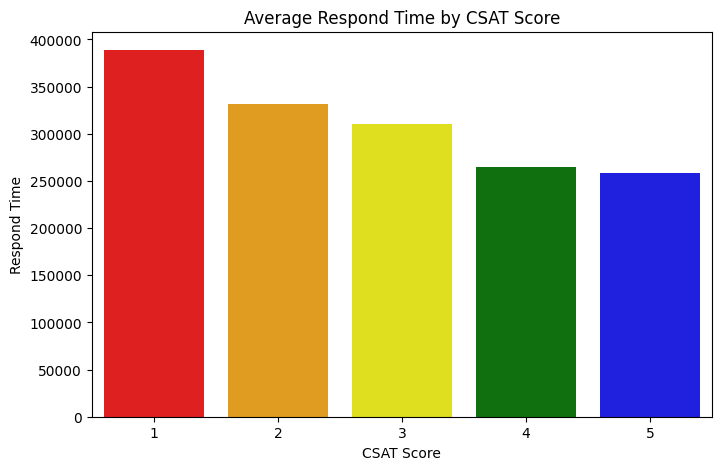

In [27]:
# Resolution Time by CSAT relation visualization code
custom_palette = {
    '1': 'red',
    '2': 'orange',
    '3': 'yellow',
    '4': 'green',
    '5': 'blue'
}
plt.figure(figsize=(8, 5))
avg_respond_time = df.groupby('CSAT Score')['resolution_time'].mean().reset_index()
sns.barplot(x='CSAT Score', y='resolution_time', data=avg_respond_time, palette=custom_palette)
plt.xlabel('CSAT Score')
plt.ylabel('Respond Time')
plt.title("Average Respond Time by CSAT Score")
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen to compare the average resolution time across different CSAT score levels. It clearly highlights differences in response time for each satisfaction rating, making it easy to identify trends between service efficiency and customer satisfaction.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above chart:-

1. Customers giving a CSAT score of 1 experienced the highest average resolution time.
2. The average resolution time gradually decreases as the CSAT score increases from 1 to 5.
3. Customers with a CSAT score of 5 had the shortest average resolution time, indicating faster issue resolution.
4. The chart suggests a negative relationship between resolution time and customer satisfaction, where quicker resolutions are associated with higher CSAT scores.

##### 3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Longer resolution times are associated with lower customer satisfaction, which can increase customer dissatisfaction, complaints, and churn. Reducing response and resolution times can improve CSAT scores, strengthen customer loyalty, and enhance the overall efficiency of customer support operations.

#### Chart - 8 - Channels by CSAT Score

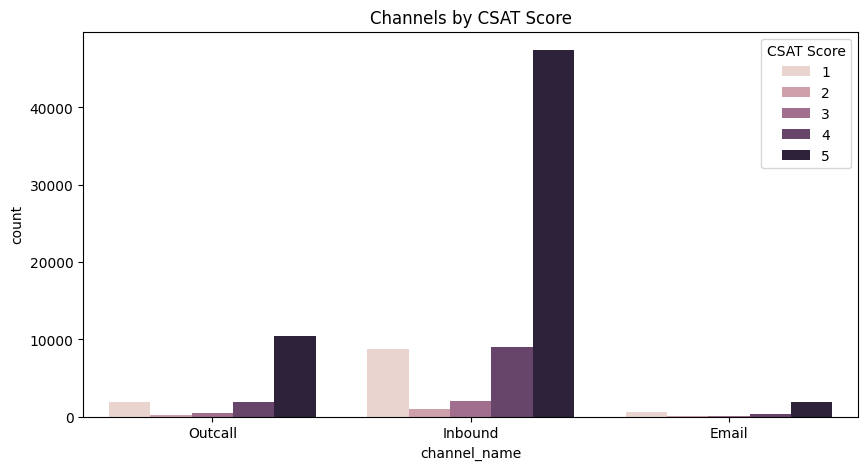

In [28]:
# Channels by CSAT Score relation visualization code
plt.figure(figsize=(10, 5))
sns.countplot(x='channel_name', hue='CSAT Score', data=df)
plt.title("Channels by CSAT Score")
plt.show()

##### 1. Why did you pick the specific chart?

A count plot with hue was chosen to compare the distribution of CSAT scores across different customer support channels. It allows easy comparison of satisfaction levels within each channel and helps identify which channels receive higher or lower customer ratings.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above chart:-

1. Inbound is the most frequently used support channel and records the highest number of CSAT score 5 responses.
2. Outcall also has a majority of CSAT score 5 ratings, although with a much lower number of interactions than Inbound.
3. Email receives the fewest customer interactions but still shows a higher proportion of CSAT score 5 compared to lower ratings.
4. Across all three channels, CSAT score 5 is the most common rating, indicating generally high customer satisfaction regardless of the communication channel.

##### 3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The chart shows that all support channels are capable of achieving high customer satisfaction, especially the Inbound channel. However, the presence of lower CSAT scores (1–3), particularly in Inbound due to its large interaction volume, indicates opportunities to improve service quality. Analyzing the causes of these lower ratings can help reduce customer dissatisfaction, improve support performance, and maintain consistently high CSAT scores across all channels.

#### Chart - 9 - Managers by CSAT Score

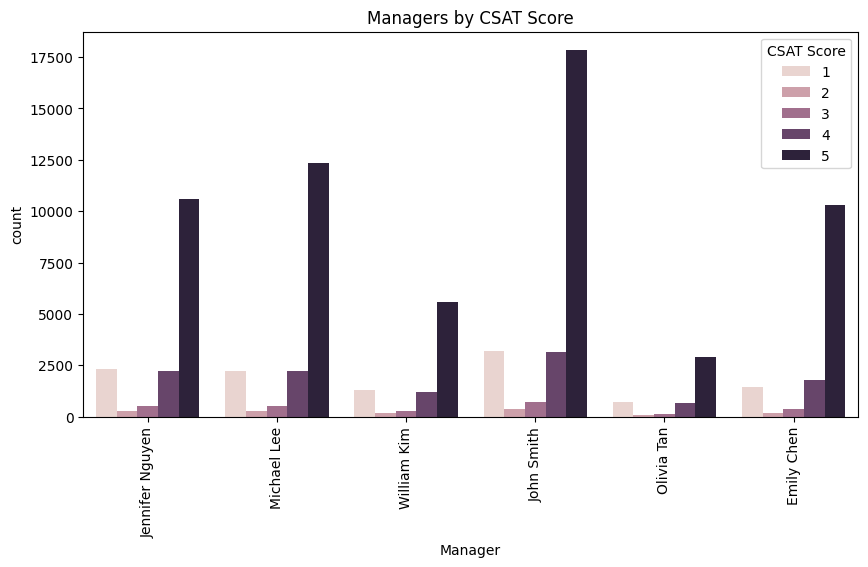

In [29]:
# Manager to CSAT Score relation visualization code
plt.figure(figsize=(10, 5))
sns.countplot(x='Manager', hue='CSAT Score', data=df)
plt.title("Managers by CSAT Score")
plt.xticks(rotation=90)
plt.show()

##### 1. Why did you pick the specific chart?

A count plot with hue was chosen to compare the distribution of CSAT scores across different managers. It helps identify whether customer satisfaction varies by manager and highlights which managers receive more high or low satisfaction ratings.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above chart:-

1. John Smith has the highest number of CSAT score 5 ratings, indicating strong customer satisfaction under his management.
2. Michael Lee, Jennifer Nguyen, and Emily Chen also receive a large number of CSAT score 5 responses, suggesting consistently positive customer experiences.
3. William Kim and Olivia Tan have fewer overall interactions, resulting in lower counts across all CSAT score categories.
4. Across all managers, CSAT score 5 is the most common rating, indicating that high customer satisfaction is consistently achieved regardless of manager.

##### 3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The chart helps identify managers who consistently oversee highly rated customer interactions, allowing organizations to recognize effective management practices and share them across teams. Managers with comparatively fewer high CSAT ratings can be provided with targeted coaching and performance improvements, leading to better service quality and higher overall customer satisfaction.

#### Chart - 10 - Supervisor by CSAT Score

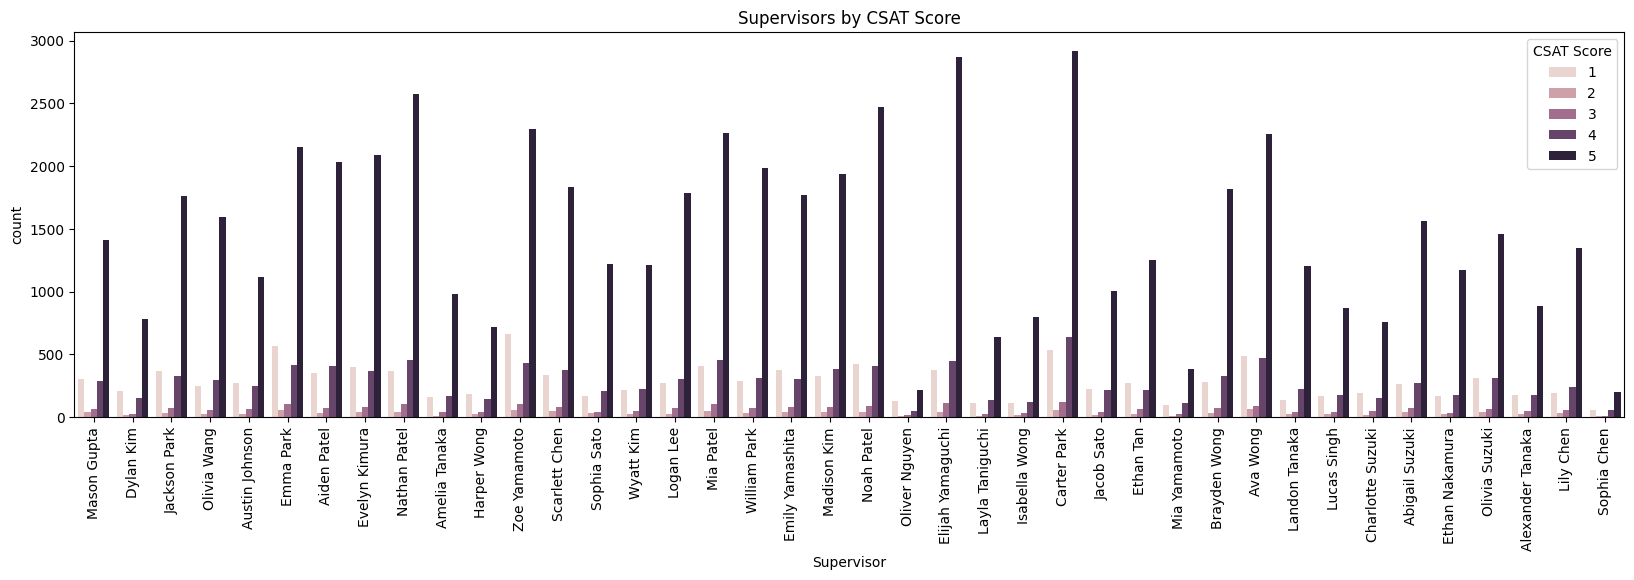

In [30]:
# Superviser to CSAT Score relation visualization code
plt.figure(figsize=(20, 5))
sns.countplot(x='Supervisor', hue='CSAT Score', data=df)
plt.title("Supervisors by CSAT Score")
plt.xticks(rotation=90)
plt.show()

##### 1. Why did you pick the specific chart?

A count plot with hue was chosen to compare the distribution of CSAT scores across different supervisors. It enables comparison of customer satisfaction ratings for each supervisor and helps identify whether any supervisor consistently oversees higher or lower customer satisfaction.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above chart:-

1. Across nearly all supervisors, CSAT score 5 has the highest frequency, indicating that most supervisors oversee highly satisfactory customer interactions.
2. The number of customer interactions varies considerably among supervisors, with some handling substantially more cases than others.
3. Lower CSAT scores (1–3) occur much less frequently than higher scores (4–5) for almost every supervisor.
4. The consistent dominance of CSAT score 5 across supervisors suggests that customer satisfaction is generally maintained at a high level throughout the support team.

##### 3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The chart helps identify supervisors who consistently manage teams with high customer satisfaction, allowing organizations to recognize effective leadership practices and apply them across the support department. Supervisors with relatively more low CSAT ratings can be targeted for coaching and process improvements, leading to better team performance, improved service quality, and higher customer satisfaction.

#### Chart - 11 - Time Difference by Agent Shift

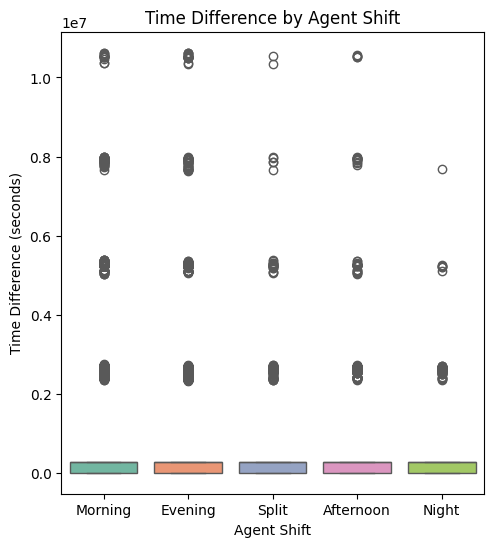

In [31]:
# Boxplot of Time Difference by Agent Shift
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 2)
sns.boxplot(x='Agent Shift', y='resolution_time', data=df, palette='Set2')
plt.title('Time Difference by Agent Shift')
plt.xlabel('Agent Shift')
plt.ylabel('Time Difference (seconds)')
plt.show()

##### 1. Why did you pick the specific chart?

A strip plot was chosen to visualize the distribution of resolution time across different agent shifts. It clearly shows the spread of response times, variations, and potential outliers within each shift, making it easy to compare operational performance.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above chart:-

1. Resolution times are widely distributed across all agent shifts, indicating considerable variation in how quickly customer issues are resolved.
2. Morning, Evening, Afternoon, and Split shifts show similar response time patterns, suggesting no major difference in service efficiency between these shifts.
3. Night shift contains comparatively fewer observations but follows a similar distribution to the other shifts.
4. Very high resolution time outliers are present across almost every shift, indicating that a small number of cases require significantly longer handling times regardless of shift.

##### 3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The chart helps managers identify whether response times differ across work shifts and whether specific shifts require additional staffing or operational improvements. The presence of extreme resolution-time outliers across all shifts suggests that certain cases experience significant delays, which may reduce customer satisfaction if not addressed. Monitoring these delays can help improve service consistency, reduce resolution times, and enhance overall customer experience.

#### Chart - 12 - Channel Type Count

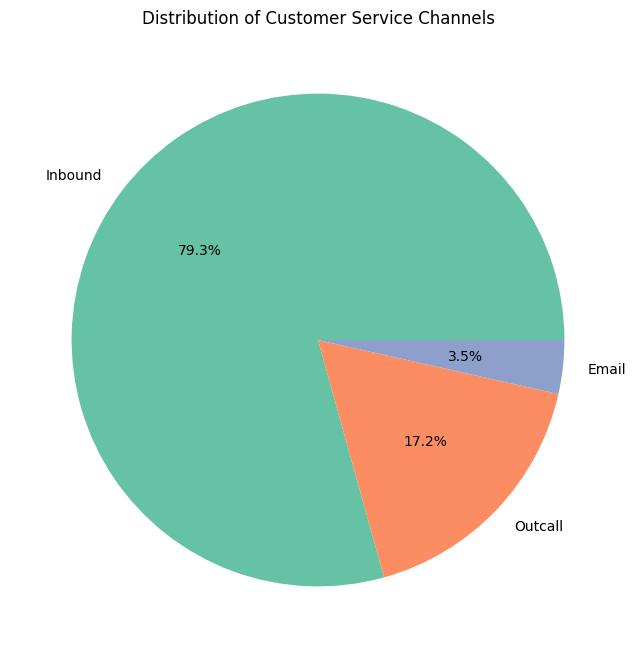

In [32]:
# Count of occurrences of channel types
channel_counts = df['channel_name'].value_counts()

# Plot Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(
    channel_counts,
    labels=channel_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('Set2')
)
plt.title('Distribution of Customer Service Channels')
plt.show()

##### 1. Why did you pick the specific chart?

A pie chart was chosen to visualize the proportion of customer support requests handled through each service channel. It provides a clear comparison of the relative share of Inbound, Outcall, and Email interactions.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above chart:-

1. Inbound is the dominant customer support channel, accounting for approximately 79.3% of all interactions.
2. Outcall contributes around 17.2% of the total customer service requests, making it the second most used channel.
3. Email represents only 3.5% of interactions, indicating that it is the least preferred communication channel.
4. The distribution shows that customer support operations rely heavily on inbound communication, with comparatively limited use of email support.

##### 3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The chart helps organizations allocate customer support resources based on actual channel demand. Since nearly 80% of requests arrive through the Inbound channel, sufficient staffing and infrastructure should be prioritized there. The very low usage of the Email channel may indicate lower customer preference or slower response experiences, suggesting an opportunity to improve digital support services and encourage balanced channel utilization.

#### Chart - 13 - CSAT Score by Agent Shift

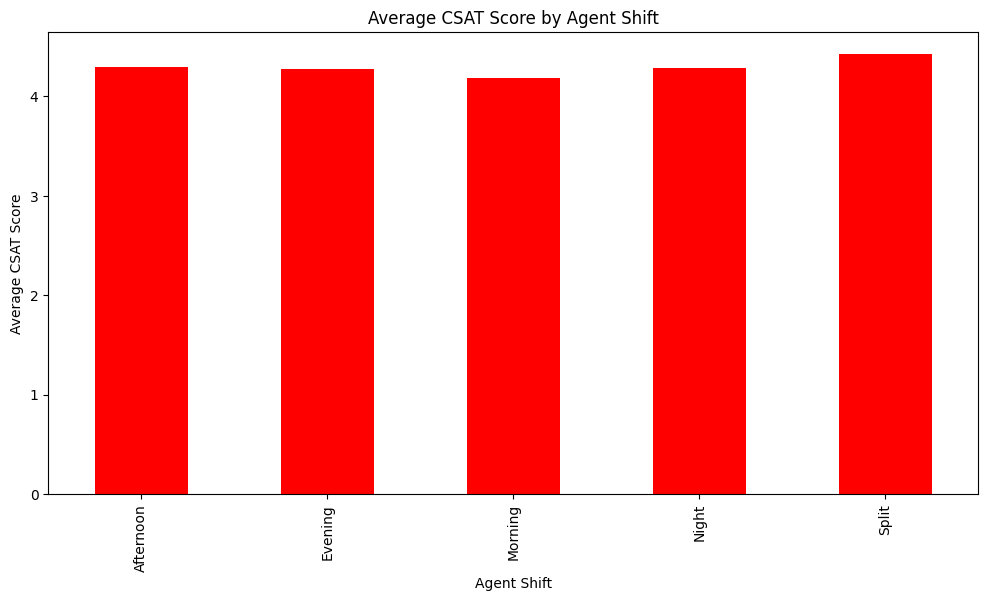

In [33]:
# Agent Shift vs CSAT Score
plt.figure(figsize=(12, 6))
df.groupby('Agent Shift')['CSAT Score'].mean().plot(kind='bar', color='red')
plt.title('Average CSAT Score by Agent Shift')
plt.xlabel('Agent Shift')
plt.ylabel('Average CSAT Score')
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen to compare the average CSAT score across different agent shifts. It clearly highlights which shifts achieve higher or lower customer satisfaction, making it easy to identify performance differences between work schedules.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above chart:-

1. The Split shift has the highest average CSAT score, indicating the best overall customer satisfaction.
2. The Morning shift records the lowest average CSAT score, suggesting relatively lower customer satisfaction.
3. The Afternoon, Evening, and Night shifts have very similar average CSAT scores, indicating consistent service quality across these shifts.
4. The difference in average CSAT across shifts is relatively small, showing that agent shift has only a limited impact on overall customer satisfaction.

##### 3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This chart helps managers identify which work shifts consistently deliver better customer satisfaction. Since the Split shift performs slightly better, its staffing practices or operational strategies can be studied and applied to other shifts. Additional training and resource planning for lower-performing shifts, such as the Morning shift, can further improve customer satisfaction and ensure consistent service quality throughout the day.

#### Chart - 14 - CSAT Score by Category

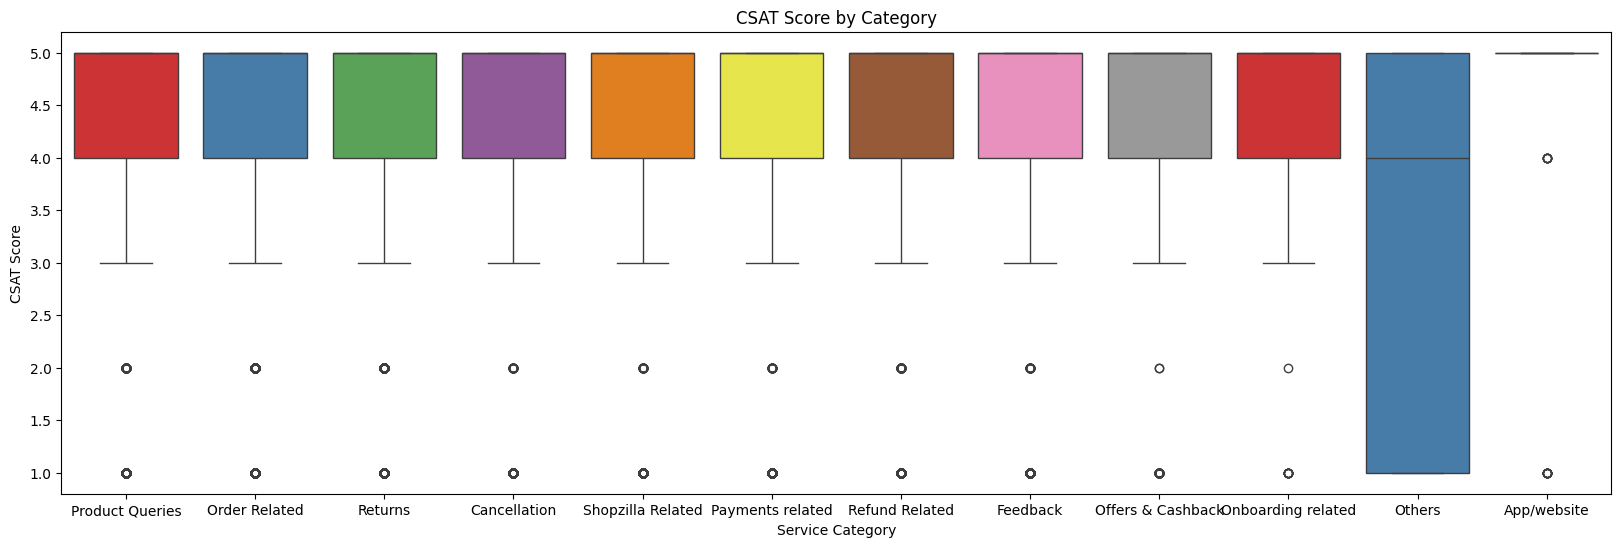

In [34]:
# CSAT Score by service category
plt.figure(figsize=(20, 6))
sns.boxplot(x='category', y='CSAT Score', data=df, palette='Set1')
plt.title('CSAT Score by Category')
plt.xlabel('Service Category')
plt.ylabel('CSAT Score')
plt.show()

##### 1. Why did you pick the specific chart?

A box plot was chosen to compare the distribution of CSAT scores across different service categories. It effectively displays the median, spread, and outliers, making it easy to identify which categories have more consistent or variable customer satisfaction.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above chart:-

1. Most service categories have a median CSAT score close to 5, indicating generally high customer satisfaction.
2. Nearly all categories contain a few low-score outliers (CSAT 1–2), showing that negative customer experiences occur across different issue types.
3. The "Others" category shows the widest variation in CSAT scores, suggesting more inconsistent customer experiences.
4. The "App/Website" category appears to have consistently high CSAT scores with very little variation, although it represents fewer interactions.

##### 3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This chart helps organizations identify service categories that deliver consistent customer satisfaction and those with greater variability. Categories with wider score distributions, such as Others, should be investigated to understand the causes of inconsistent service. Addressing these issues can improve service quality, increase customer satisfaction, and reduce negative customer experiences.

#### Chart - 15 - CSAT Score by Agent Tenure

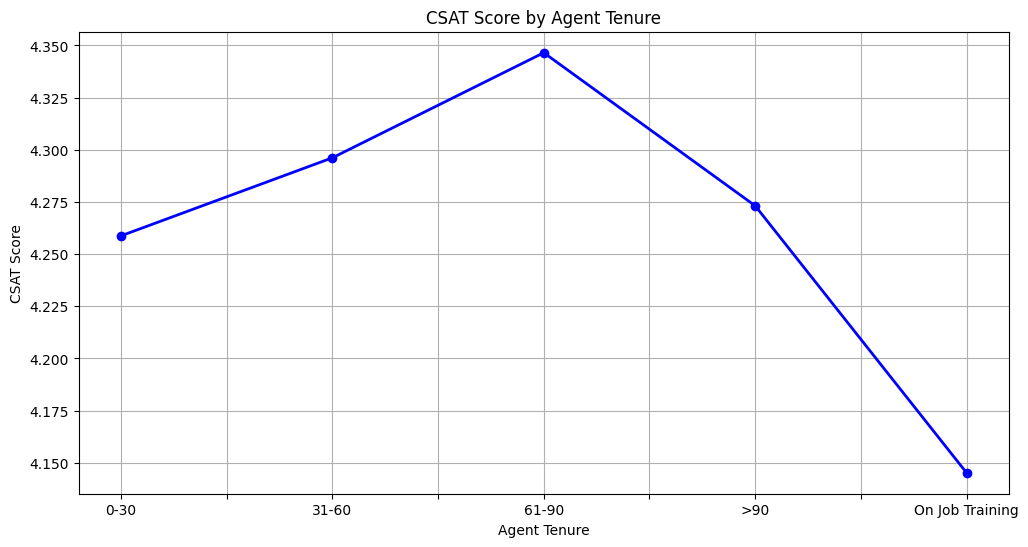

In [35]:
# Agent Tenure vs CSAT Score
plt.figure(figsize=(12, 6))
tenure_scores = df.groupby('Tenure Bucket')['CSAT Score'].mean()
tenure_scores.plot(kind='line', marker='o', color='blue', linestyle='-', linewidth=2)
plt.title('CSAT Score by Agent Tenure')
plt.xlabel('Agent Tenure')
plt.ylabel('CSAT Score')
plt.grid(True)
plt.show()

##### 1. Why did you pick the specific chart?

A line chart was chosen to visualize how the average CSAT score changes across different agent tenure groups. It clearly highlights trends and makes it easy to observe whether customer satisfaction improves or declines with agent experience.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above chart:-

1. Agents with 61–90 days of tenure achieve the highest average CSAT score, indicating the best customer satisfaction.
2. On Job Training agents have the lowest average CSAT score, suggesting that newly trained agents may require additional support.
3. Customer satisfaction generally increases from 0–30 days to 61–90 days, then declines slightly for agents with more than 90 days of tenure.
4. The differences in average CSAT across tenure groups are relatively small, indicating that tenure has a moderate but noticeable impact on customer satisfaction.

##### 3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This chart helps organizations evaluate how agent experience influences customer satisfaction. The lower CSAT scores for agents in training highlight the need for improved onboarding and mentoring, while the strong performance of agents with 61–90 days of experience can be used as a benchmark for training programs. These insights can improve workforce development, increase customer satisfaction, and enhance overall service quality.

#### Chart - 16 - Resolution Time Distribution

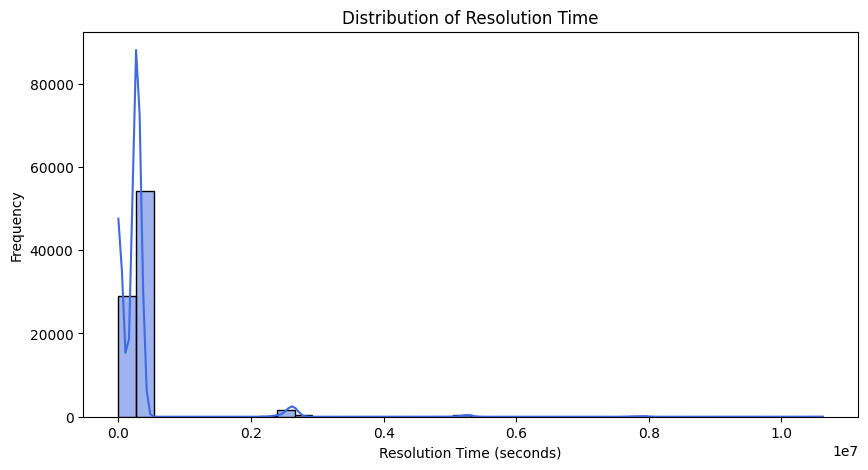

In [36]:
# Plot Distibution of Resolution Time
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='resolution_time',
    bins=40,
    kde=True,
    color='royalblue'
)

plt.title("Distribution of Resolution Time")
plt.xlabel("Resolution Time (seconds)")
plt.ylabel("Frequency")
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with a Kernel Density Estimate (KDE) was chosen to visualize the distribution of the engineered feature resolution_time. This chart clearly shows the frequency, spread, skewness, and presence of extreme values, making it useful for understanding how quickly customer issues are typically resolved before building the classification model.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above chart:-

1. The distribution of resolution_time is highly right-skewed, with most customer issues being resolved within a relatively short period.
2. A small number of cases have extremely long resolution times, indicating the presence of significant outliers.
3. The large concentration of observations near the lower end suggests that customer support generally resolves issues efficiently for most customers.
4. The skewed distribution indicates that applying transformations or robust scaling may improve model performance during machine learning.

##### 3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The chart shows that while most customer issues are resolved quickly, a small number of cases experience exceptionally long resolution times. These delayed cases may lead to customer dissatisfaction and lower CSAT scores. Identifying the reasons behind these outliers can help Flipkart streamline its support process, reduce resolution delays, improve operational efficiency, and enhance overall customer satisfaction.

#### Chart - 17 - Resolution Time by Channel

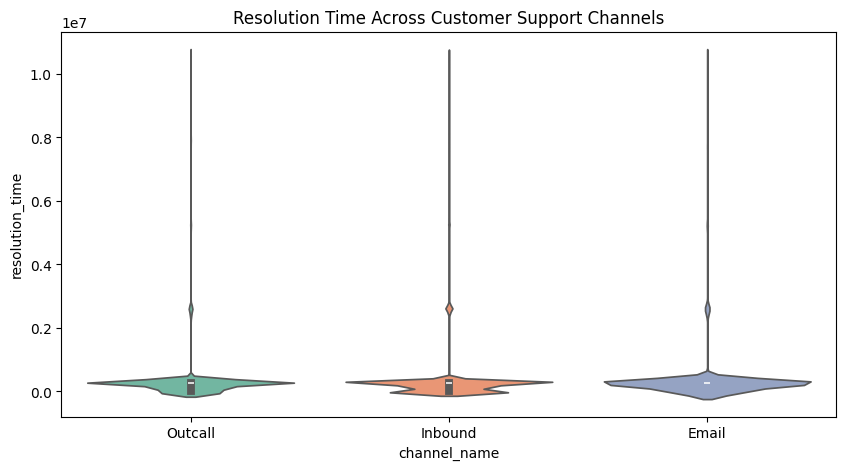

In [37]:
# Plot Resolution Time by channel name
plt.figure(figsize=(10,5))

sns.violinplot(
    data=df,
    x='channel_name',
    y='resolution_time',
    palette='Set2'
)

plt.title("Resolution Time Across Customer Support Channels")
plt.show()

##### 1. Why did you pick the specific chart?

A violin plot was chosen to compare the distribution of resolution time across different customer support channels. Unlike a box plot, it shows both the spread and density of the data, making it easier to identify variations, skewness, and extreme values within each communication channel.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above chart:-

1. All three support channels (Inbound, Outcall, and Email) exhibit similarly right-skewed resolution time distributions with several extreme outliers.
2. The majority of customer interactions in each channel are resolved within a relatively short time, while only a few cases require exceptionally long resolution times.
3. No single channel appears to consistently have significantly faster or slower resolution times, indicating comparable operational performance across channels.
4. The presence of long-tail outliers in every channel suggests that complex customer issues can occur regardless of the communication channel used.

##### 3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The chart helps identify whether a particular customer support channel experiences longer resolution times than others. Although the overall distributions are similar, the extreme outliers across all channels indicate that some customer issues remain unresolved for extended periods. Reducing these delays through improved routing, agent training, or escalation processes can enhance customer satisfaction, improve operational efficiency, and increase overall service quality.

#### Chart - 18 - Resolution Time by Agent Tenure

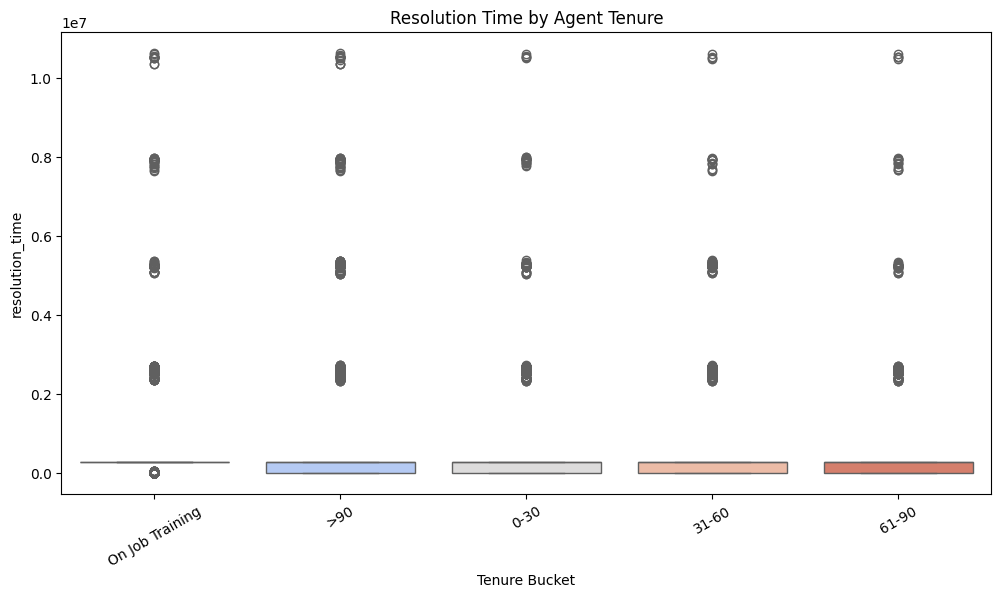

In [38]:
# Plot Resolution Time by Agent Tenure
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='Tenure Bucket',
    y='resolution_time',
    palette='coolwarm'
)

plt.xticks(rotation=30)
plt.title("Resolution Time by Agent Tenure")
plt.show()

##### 1. Why did you pick the specific chart?

A box plot was chosen to compare the distribution of resolution time across different agent tenure groups. It effectively displays the median, spread, variability, and outliers for each tenure category, making it easy to identify whether agent experience influences the time taken to resolve customer issues.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above chart:-

1. Resolution time distributions are broadly similar across all tenure groups, suggesting that experience alone does not significantly affect issue resolution speed.
2. Every tenure category contains several extreme outliers, indicating that prolonged resolution times occur regardless of an agent's experience level.
3. The median resolution times remain relatively close across all groups, showing consistent operational performance among agents with different tenure levels.
4. The comparable spread of the box plots suggests that complex customer issues, rather than agent tenure, are likely the primary reason for unusually long resolution times.

##### 3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The chart indicates that long resolution times are not limited to newly hired agents but occur across all tenure groups. This suggests that delays may stem from process inefficiencies or complex customer cases rather than lack of experience. By improving workflows, enhancing knowledge management, and optimizing escalation procedures, Flipkart can reduce prolonged resolution times, improve service consistency, and increase customer satisfaction across the entire support team.

#### Chart - 19 - Correlation Heatmap

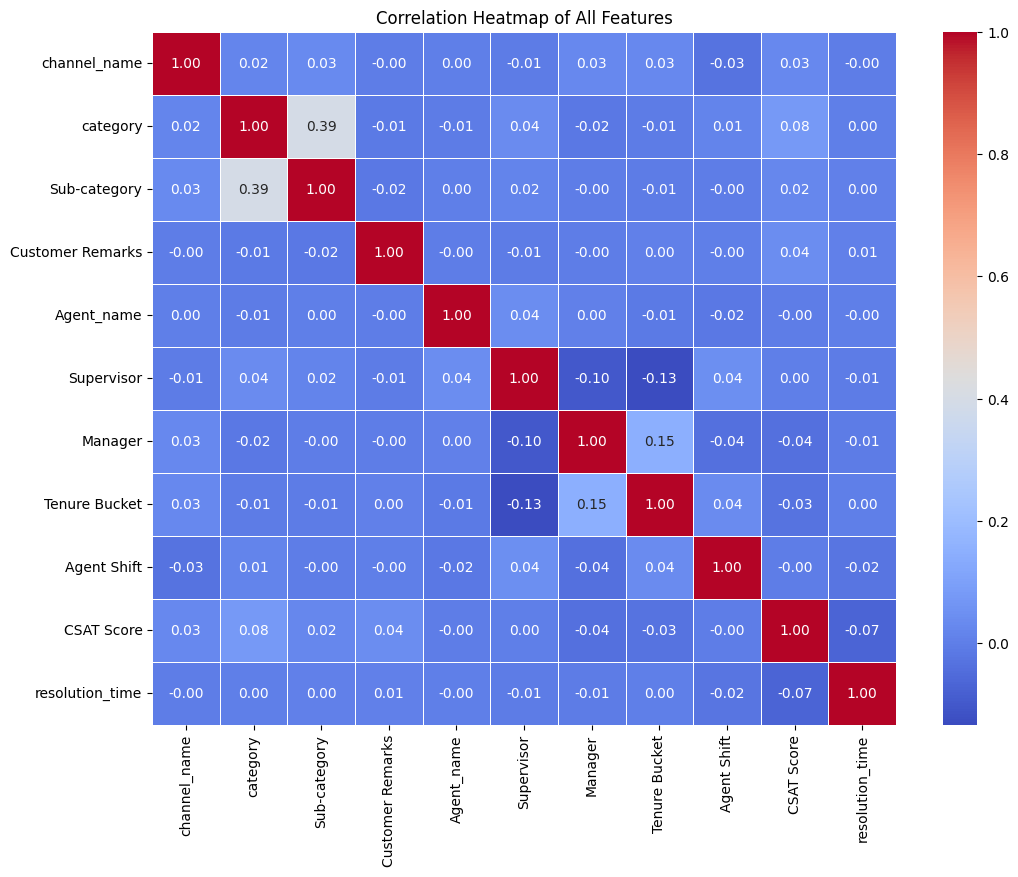

In [39]:
# Correlation Heatmap visualization code
encoded_df = df.copy()

le = LabelEncoder()

for col in encoded_df.columns:
    if encoded_df[col].dtype == "object":
        encoded_df[col] = le.fit_transform(encoded_df[col].astype(str))

plt.figure(figsize=(12,9))

sns.heatmap(
    encoded_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of All Features")
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap was chosen to examine the strength and direction of relationships between all encoded features in the dataset. It provides a quick visual summary of how variables are associated with one another and helps identify potential correlations, redundant features, or variables that may influence the target during model development.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above chart:-

1. Most feature pairs have correlation coefficients close to 0, indicating weak linear relationships and low multicollinearity among the variables.
2. Category and Sub-category show the strongest positive correlation (approximately 0.39), which is expected because sub-categories belong to broader service categories.
3. CSAT Score has only a weak negative correlation with resolution_time (approximately -0.07), suggesting that longer resolution times have only a slight impact on customer satisfaction.
4. The low correlations among most features indicate that each variable contributes unique information, which is beneficial for building robust machine learning models.

##### 3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The heatmap helps identify relationships between operational variables and customer satisfaction. The slight negative relationship between resolution_time and CSAT Score suggests that reducing issue resolution time can improve customer satisfaction. Additionally, the low multicollinearity among features indicates that the dataset contains diverse information, enabling the development of more accurate and reliable predictive models for customer service optimization.

#### Chart - 20 - Pair Plot

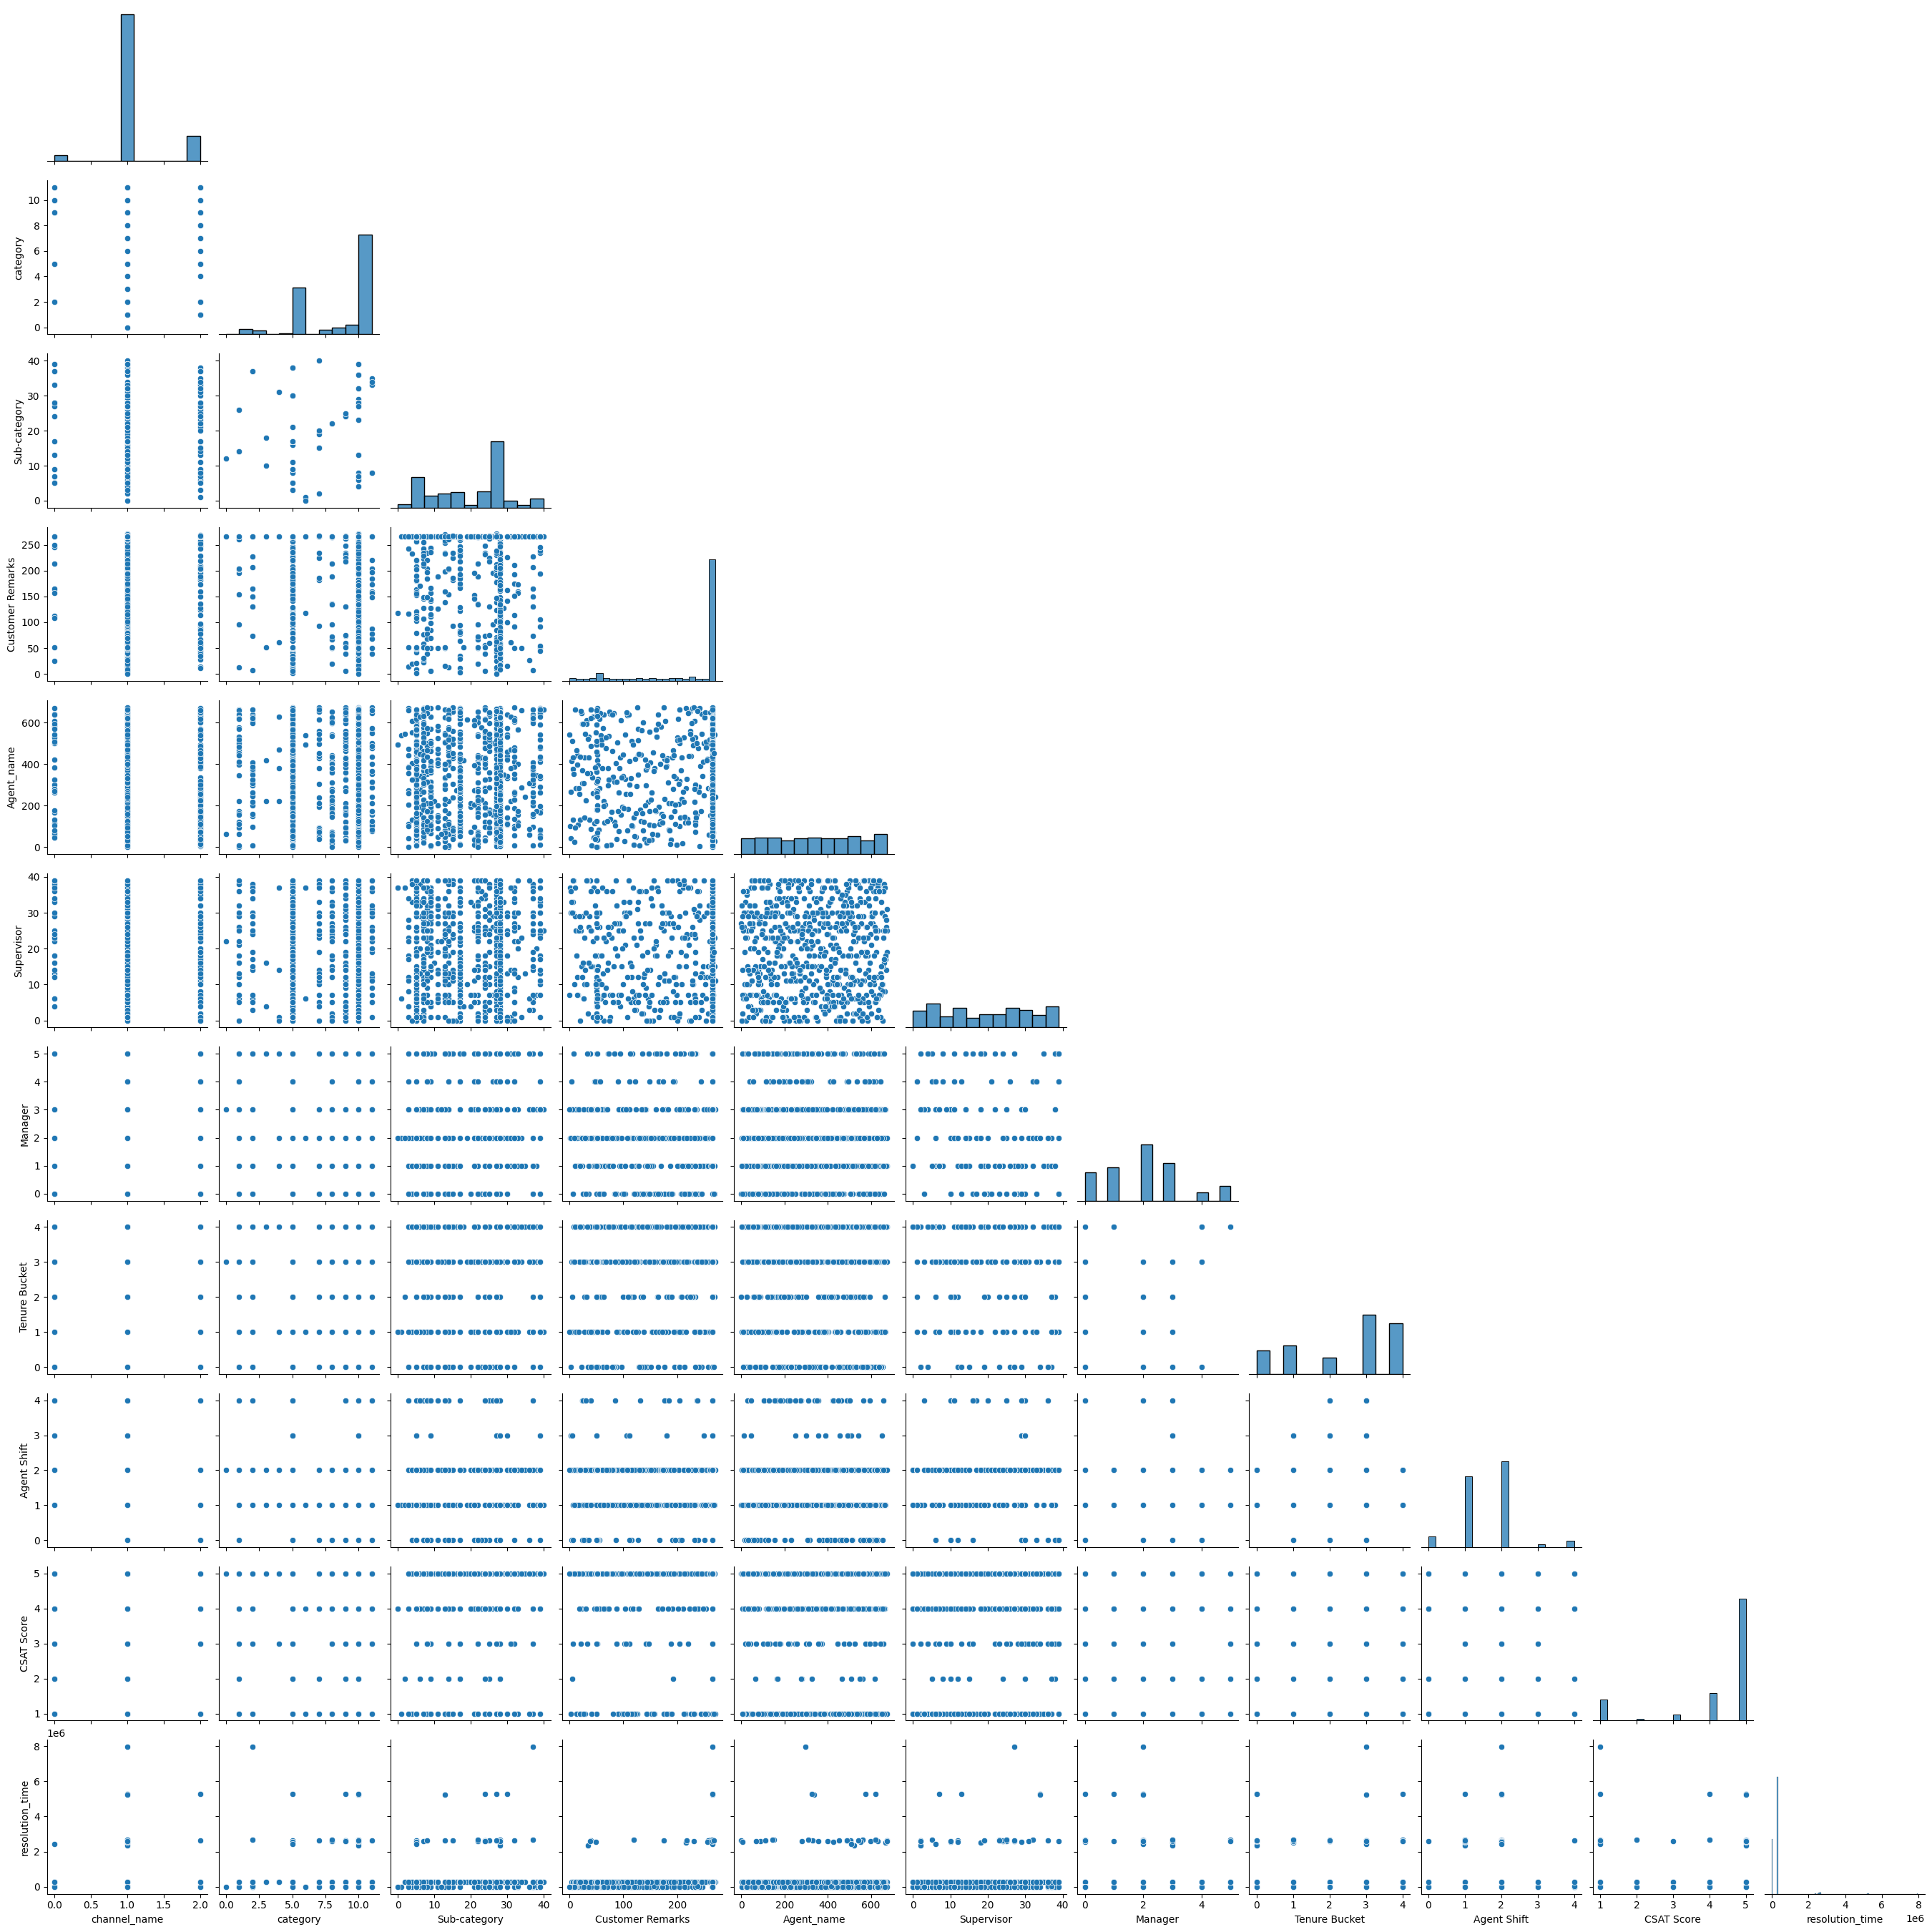

In [40]:
# Pair Plot visualization code

# Take a random sample of 1000 rows
pair_df = df.sample(n=1000, random_state=42).copy()

# Encode categorical columns
for col in pair_df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    pair_df[col] = le.fit_transform(pair_df[col].astype(str))

# Plot pairplot
sns.pairplot(
    pair_df,
    corner=True,
    diag_kind='hist'
)

plt.show()

##### 1. Why did you pick the specific chart?

A pair plot was chosen to visualize the relationships between all features in the dataset simultaneously. It combines scatter plots and distribution plots to identify correlations, clusters, trends, and potential outliers, providing a comprehensive overview of the data before machine learning model development.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above chart:-

1. Most feature combinations do not exhibit strong linear relationships, indicating that the variables capture different aspects of customer service interactions.
2. The diagonal plots show the distribution of individual features, revealing that several encoded categorical variables are concentrated into distinct groups.
3. The scatter plots display no obvious clustering or separation between most feature pairs, supporting the findings from the correlation heatmap that multicollinearity is low.
4. A few variables, such as Category and Sub-category, exhibit some degree of association, while the remaining features appear largely independent.

##### 3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The pair plot confirms that the dataset contains diverse and largely independent features, which is beneficial for building accurate predictive models. The absence of strong multicollinearity reduces the risk of redundant information affecting model performance. Additionally, identifying variables with weak or no relationships helps prioritize the most informative features during feature selection, leading to better customer satisfaction prediction and more effective decision-making.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

### Hypothetical Statement - 1

#### 1. Does the customer support channel influence customer satisfaction (CSAT Score)?

#### Null Hypothesis (H₀)

The mean CSAT Score is the same across all customer support channels.

#### Alternative Hypothesis (H₁)

At least one customer support channel has a significantly different mean CSAT Score.

#### 2. Perform One-Way ANOVA

In [41]:
# Perform One-Way ANOVA for obtaining P-Value

groups = [
    group["CSAT Score"].values
    for _, group in df.groupby("channel_name")
]

f_stat, p = f_oneway(*groups)

print("F Statistic:", f_stat)
print("P-value:", p)

alpha = 0.05

if p < alpha:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

F Statistic: 98.28210579751084
P-value: 2.3194399795949356e-43
Reject Null Hypothesis


##### Which statistical test have you done to obtain P-Value?

One-Way ANOVA (Analysis of Variance).

##### Why did you choose the specific statistical test?

The customer support channel is a categorical variable with multiple groups (Inbound, Outcall, and Email), while CSAT Score is treated as a numerical rating. One-Way ANOVA is appropriate for determining whether the mean CSAT Score differs significantly across multiple customer support channels.

Conclusion based on P-Value

Since P-value < 0.05, the null hypothesis is rejected and conclude that customer support channel has a statistically significant effect on the mean CSAT Score.

### Hypothetical Statement - 2

#### 1. Does resolution time significantly affect customer satisfaction?

#### Null Hypothesis (H₀)

The mean resolution time is the same across all CSAT Score groups.

#### Alternative Hypothesis (H₁)

At least one CSAT Score group has a significantly different mean resolution time.

#### 2. Perform One-Way ANOVA

In [42]:
# Perform One-Way ANOVA for obtaining P-Value

groups = [group["resolution_time"].values
          for _, group in df.groupby("CSAT Score")]

f_stat, p = f_oneway(*groups)

print("F Statistic:", f_stat)
print("P-value:", p)

alpha = 0.05

if p < alpha:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

F Statistic: 109.620389851663
P-value: 2.3325004417315132e-93
Reject Null Hypothesis


##### Which statistical test have you done to obtain P-Value?

One-Way ANOVA (Analysis of Variance).

##### Why did you choose the specific statistical test?

One-Way ANOVA was selected because the objective is to compare the mean resolution time across multiple CSAT Score groups (1–5). ANOVA is appropriate when comparing the means of a continuous variable across more than two independent groups.

Conclusion based on P-Value

Since P-value < 0.05, the null hypothesis is rejected and it is concluded that resolution time differs significantly across CSAT Score groups.

### Hypothetical Statement - 3

#### 1. Does the agent shift influence customer satisfaction (CSAT Score)?

#### Null Hypothesis (H₀)

The mean CSAT Score is the same across all agent shifts.

#### Alternative Hypothesis (H₁)

At least one agent shift has a significantly different mean CSAT Score.

#### 2. Perform One-Way ANOVA

In [43]:
# Perform One-Way ANOVA for obtaining P-Value

groups = [
    group["CSAT Score"].values
    for _, group in df.groupby("Agent Shift")
]

f_stat, p = f_oneway(*groups)

print("F Statistic:", f_stat)
print("P-value:", p)

alpha = 0.05

if p < alpha:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

F Statistic: 39.1131806276633
P-value: 9.030515405320748e-33
Reject Null Hypothesis


##### Which statistical test have you done to obtain P-Value?

One-Way ANOVA (Analysis of Variance).

##### Why did you choose the specific statistical test?

Agent Shift is a categorical variable with multiple groups (Morning, Afternoon, Evening, Night, and Split), while CSAT Score is treated as a numerical rating. One-Way ANOVA is suitable for determining whether the average CSAT Score differs significantly across different work shifts.

Since P-value < 0.05, the null hypothesis is rejected and it is concluded that agent shift has a statistically significant effect on the average CSAT Score.

## 6. ***Data Pre-processing***

### 1. Handling Missing/Null Values

In [44]:
# Check for Missing Values
df.isnull().sum()

channel_name            0
category                0
Sub-category            0
Customer Remarks    57165
Agent_name              0
Supervisor              0
Manager                 0
Tenure Bucket           0
Agent Shift             0
CSAT Score              0
resolution_time         0
dtype: int64

In [45]:
# Removing null values
df['Customer Remarks'] = df['Customer Remarks'].fillna('Missing')

In [46]:
# Verifying Removal of Null Values
df.isnull().sum()

channel_name        0
category            0
Sub-category        0
Customer Remarks    0
Agent_name          0
Supervisor          0
Manager             0
Tenure Bucket       0
Agent Shift         0
CSAT Score          0
resolution_time     0
dtype: int64

In [47]:
# Create a copy before handling outliers
df_before = df.copy()

### 2. Handling Outliers

In [48]:
# Handling Outliers using the IQR Method

# Calculate the First Quartile (Q1)
Q1 = df['resolution_time'].quantile(0.25)

# Calculate the Third Quartile (Q3)
Q3 = df['resolution_time'].quantile(0.75)

# Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# Determine the lower and upper limits for outliers
lower_limit = Q1 - (1.5 * IQR)
upper_limit = Q3 + (1.5 * IQR)

# Display the calculated limits
print("Lower Limit :", lower_limit)
print("Upper Limit :", upper_limit)

# Count the number of outliers before treatment

outliers = df[
    (df['resolution_time'] < lower_limit) |
    (df['resolution_time'] > upper_limit)
]

print("Number of Outliers Before Treatment :", len(outliers))

df['resolution_time'] = df['resolution_time'].clip(
    lower=lower_limit,
    upper=upper_limit
)

# Verify Outlier Removal

remaining_outliers = df[
    (df['resolution_time'] < lower_limit) |
    (df['resolution_time'] > upper_limit)
]

print("Number of Outliers After Treatment :", len(remaining_outliers))

Lower Limit : -415393.6993013625
Upper Limit : 695362.8321689374
Number of Outliers Before Treatment : 2660
Number of Outliers After Treatment : 0


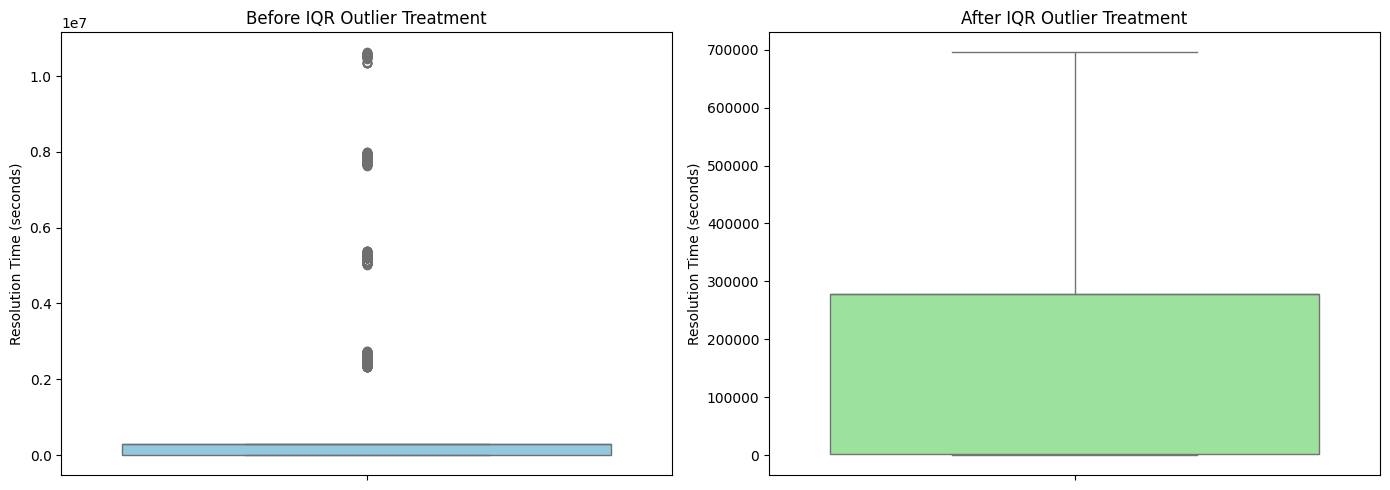

In [49]:
# Compare Before and After Outlier Treatment

plt.figure(figsize=(14,5))

# Before Outlier Treatment
plt.subplot(1,2,1)
sns.boxplot(y=df_before['resolution_time'], color='skyblue')
plt.title("Before IQR Outlier Treatment")
plt.ylabel("Resolution Time (seconds)")

# After Outlier Treatment
plt.subplot(1,2,2)
sns.boxplot(y=df['resolution_time'], color='lightgreen')
plt.title("After IQR Outlier Treatment")
plt.ylabel("Resolution Time (seconds)")

plt.tight_layout()
plt.show()

In [50]:
# Displaying number of Outliers removed

print("Lower Limit :", lower_limit)
print("Upper Limit :", upper_limit)

print("Outliers Before Treatment :", len(outliers))
print("Outliers After Treatment :", len(remaining_outliers))

Lower Limit : -415393.6993013625
Upper Limit : 695362.8321689374
Outliers Before Treatment : 2660
Outliers After Treatment : 0


##### What all outlier treatment techniques have you used and why did you use those techniques?



The Interquartile Range (IQR) method was used to detect and handle outliers in the resolution_time feature. Outliers were identified using the lower bound (Q1 − 1.5 × IQR) and upper bound (Q3 + 1.5 × IQR). Instead of removing records, the detected outliers were capped (winsorized) to the calculated upper and lower limits using the clip() function.

Reason for Using This Technique:

The IQR method is a robust statistical technique that effectively identifies extreme values without being affected by skewed distributions. Since customer service resolution times naturally contain a few unusually long cases, removing those observations could lead to loss of valuable information. Therefore, capping the outliers preserves all records while reducing the influence of extreme values on the machine learning models. This improves model stability, minimizes the impact of outliers, and maintains the integrity of the dataset.

### 3. Categorical Encoding

In [51]:
num_cols = df.select_dtypes(include=['number']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Numerical features : ", num_cols)
print("Categorical features : ", cat_cols)

Numerical features :  ['CSAT Score', 'resolution_time']
Categorical features :  ['channel_name', 'category', 'Sub-category', 'Customer Remarks', 'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift']


In [52]:
# Separating ordinal and nominal categorical features

ordinal_cols = ['Tenure Bucket']

nominal_cols = [
    'channel_name',
    'category',
    'Sub-category',
    'Customer Remarks',
    'Agent_name',
    'Supervisor',
    'Manager',
    'Agent Shift'
]

In [53]:
# Define the natural order of Tenure Bucket
tenure_order = [['On Job Training', '0-30', '31-60', '61-90', '>90']]

ordinal_encoder = OrdinalEncoder(categories=tenure_order)

df[ordinal_cols] = ordinal_encoder.fit_transform(df[ordinal_cols])

df[ordinal_cols].head()

,Tenure Bucket
0,0.0
1,4.0
2,0.0
3,4.0
4,1.0


In [54]:
print(df.shape)
df.head()

(85907, 11)


,channel_name,category,Sub-category,Customer Remarks,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,resolution_time
0,Outcall,Product Queries,Life Insurance,Missing,Richard Buchanan,Mason Gupta,Jennifer Nguyen,0.0,Morning,5,2040.0
1,Outcall,Product Queries,Product Specific Information,Missing,Vicki Collins,Dylan Kim,Michael Lee,4.0,Morning,5,120.0
2,Inbound,Order Related,Installation/demo,Missing,Duane Norman,Jackson Park,William Kim,0.0,Evening,5,1320.0
3,Inbound,Returns,Reverse Pickup Enquiry,Missing,Patrick Flores,Olivia Wang,John Smith,4.0,Evening,5,1200.0
4,Inbound,Cancellation,Not Needed,Missing,Christopher Sanchez,Austin Johnson,Michael Lee,1.0,Morning,5,120.0


#### What all categorical encoding techniques have you used & why did you use those techniques?

Categorical encoding was performed using two techniques: Ordinal Encoding. Ordinal Encoding was applied to the 'Tenure Bucket' feature because it has a meaningful natural order based on the duration of an agent's experience. This approach converts categorical data into numerical form while preserving the relationships among features and avoiding the introduction of artificial rankings.

### 4. Textual Data Preprocessing

#### 1. Expand Contractions

In [55]:
# Expand Contractions

import contractions

df["Customer Remarks"] = df["Customer Remarks"].astype(str).apply(contractions.fix)

df[["Customer Remarks"]].head()

,Customer Remarks
0,Missing
1,Missing
2,Missing
3,Missing
4,Missing


#### 2. Lower Casing

In [56]:
# Lower Casing

df["Customer Remarks"] = (
    df["Customer Remarks"]
    .astype(str)
    .str.lower()
)

df[["Customer Remarks"]].head()

,Customer Remarks
0,missing
1,missing
2,missing
3,missing
4,missing


#### 3. Remove Punctuations

In [57]:
# Remove Punctuations

import string

df["Customer Remarks"] = (
    df["Customer Remarks"]
    .str.translate(str.maketrans('', '', string.punctuation))
)

df[["Customer Remarks"]].head()

,Customer Remarks
0,missing
1,missing
2,missing
3,missing
4,missing


#### 4. Remove URLs & Remove words and digits contain digits

In [58]:
# Remove URLs & Remove words and digits contain digits

import re

def clean_text(text):
    text = re.sub(r'http\S+|www\S+', '', text)     # Remove URLs
    text = re.sub(r'\b\w*\d\w*\b', '', text)       # Remove words containing digits
    return text

df["Customer Remarks"] = df["Customer Remarks"].apply(clean_text)

df[["Customer Remarks"]].head()

,Customer Remarks
0,missing
1,missing
2,missing
3,missing
4,missing


#### 5. Remove Stopwords and Whitespaces

In [59]:
# Remove Stopwords

from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

df["Customer Remarks"] = df["Customer Remarks"].apply(
    lambda x: " ".join(
        word for word in x.split()
        if word not in stop_words
    )
)

df[["Customer Remarks"]].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\senan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Customer Remarks
0,missing
1,missing
2,missing
3,missing
4,missing


In [60]:
# Remove White spaces

df["Customer Remarks"] = (
    df["Customer Remarks"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df[["Customer Remarks"]].head()

,Customer Remarks
0,missing
1,missing
2,missing
3,missing
4,missing


#### 6. Rephrase Text

In [61]:
# Rephrase Text

from nltk.stem import WordNetLemmatizer

nltk.download("wordnet")
nltk.download("omw-1.4")

lemmatizer = WordNetLemmatizer()

df["Customer Remarks"] = df["Customer Remarks"].apply(
    lambda x: " ".join(
        lemmatizer.lemmatize(word)
        for word in x.split()
    )
)

df[["Customer Remarks"]].head()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\senan\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\senan\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,Customer Remarks
0,missing
1,missing
2,missing
3,missing
4,missing


#### 7. Tokenization

In [62]:
# Tokenization

import nltk
from nltk.tokenize import word_tokenize

nltk.download("punkt")

df["Tokens"] = df["Customer Remarks"].apply(word_tokenize)

df[["Customer Remarks","Tokens"]].head()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\senan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,Customer Remarks,Tokens
0,missing,[missing]
1,missing,[missing]
2,missing,[missing]
3,missing,[missing]
4,missing,[missing]


#### 8. Normalizing Text

In [63]:
# Normalizing Text

from nltk.stem import WordNetLemmatizer

nltk.download("wordnet")

lemmatizer = WordNetLemmatizer()

df["Normalized Text"] = df["Tokens"].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

df[["Tokens","Normalized Text"]].head()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\senan\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,Tokens,Normalized Text
0,[missing],[missing]
1,[missing],[missing]
2,[missing],[missing]
3,[missing],[missing]
4,[missing],[missing]


In [64]:
df["Customer Remarks"]

0                                       missing
1                                       missing
2                                       missing
3                                       missing
4                                       missing
                          ...                  
85902                                   missing
85903    supported team customer executive good
85904                need improve proper detail
85905                                   missing
85906                                   missing
Name: Customer Remarks, Length: 85907, dtype: object

##### Which text normalization technique have you used and why?

The customer remarks were preprocessed using a sequence of standard Natural Language Processing (NLP) techniques to improve text quality before feature extraction and model building. First, contractions were expanded (e.g., can't → cannot) to standardize the text. All text was then converted to lowercase to eliminate case-related inconsistencies. Punctuation marks were removed because they do not contribute meaningful information for sentiment analysis. URLs, numbers, and words containing digits were removed as they are generally irrelevant to understanding customer opinions. Next, stopwords (such as the, is, and and) were removed, followed by the removal of extra white spaces to produce clean text. The cleaned text was then rephrased/normalized by converting words into a consistent format where necessary. After that, tokenization was performed to split each review into individual words for easier processing. Finally, lemmatization was applied as the text normalization technique to convert words to their dictionary (base) forms while preserving their meanings (e.g., running, runs, and ran → run). These preprocessing steps reduce noise, standardize textual data, improve feature quality, and enhance the performance of downstream sentiment analysis and machine learning models.

#### 9. POS Tagging

In [65]:
# POS Tagging

from nltk import pos_tag
from nltk.tokenize import word_tokenize

nltk.download('averaged_perceptron_tagger')
nltk.download('punkt')

# POS tagging for customer remarks
df["POS_Tags"] = df["Customer Remarks"].apply(
    lambda x: pos_tag(word_tokenize(str(x)))
)

# Display first 5 rows
df[["Customer Remarks", "POS_Tags"]].head()

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\senan\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\senan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,Customer Remarks,POS_Tags
0,missing,"[(missing, VBG)]"
1,missing,"[(missing, VBG)]"
2,missing,"[(missing, VBG)]"
3,missing,"[(missing, VBG)]"
4,missing,"[(missing, VBG)]"


#### 10. Vectorizing Text

In [66]:
# Vectorizing Text

from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=1000,
    stop_words='english'
)

# Convert text into numerical vectors
X_text = tfidf.fit_transform(df["Customer Remarks"])

print("Shape of TF-IDF Matrix :", X_text.shape)

Shape of TF-IDF Matrix : (85907, 1000)


In [67]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:20])

['aa' 'aap' 'aapka' 'aapse' 'aata' 'aaya' 'ab' 'abhi' 'abhishek' 'able'
 'absolutely' 'accept' 'access' 'accha' 'acche' 'acchi' 'according'
 'account' 'acha' 'achcha']


##### Which text vectorization technique have you used and why?

NLTK's Penn Treebank Part-of-Speech (POS) Tagger was used to assign grammatical labels (such as nouns, verbs, adjectives, and adverbs) to the words in each customer remark. POS tagging helps capture the grammatical structure of the text, making it easier to understand the context and identify meaningful linguistic patterns. After POS tagging, the cleaned customer remarks were converted into numerical representations using TF-IDF (Term Frequency–Inverse Document Frequency) vectorization. TF-IDF assigns higher weights to words that are important within a specific review while reducing the influence of commonly occurring words across all reviews. Together, POS tagging enhances the understanding of textual content, while TF-IDF transforms the processed text into feature vectors suitable for machine learning algorithms, resulting in improved sentiment analysis and customer feedback classification.

### 7. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [68]:
# Manipulate Features to minimize feature correlation and create new features

# Separate numerical and categorical features

num_cols = df.select_dtypes(include=['number']).columns.tolist()
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()

print("Numerical Features:")
print(num_cols)

print("\nCategorical Features:")
print(cat_cols)

Numerical Features:
['Tenure Bucket', 'CSAT Score', 'resolution_time']

Categorical Features:
['channel_name', 'category', 'Sub-category', 'Customer Remarks', 'Agent_name', 'Supervisor', 'Manager', 'Agent Shift', 'Tokens', 'Normalized Text', 'POS_Tags']


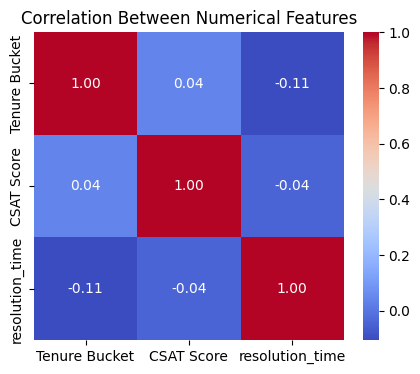

In [69]:
# Plot Correlation matrix
plt.figure(figsize=(5,4))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Between Numerical Features")
plt.show()

#### 2. Feature Selection

In [70]:
# Select your features wisely to avoid overfitting

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif

# Copy dataset
fs_df = df.copy()

# Columns generated during text preprocessing are not used
fs_df = fs_df.drop(
    columns=[
        "Tokens",
        "Normalized Text",
        "POS_Tags"
    ]
)

# Identify categorical columns
cat_cols = fs_df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

# Encode categorical variables
encoder = LabelEncoder()

for col in cat_cols:
    fs_df[col] = encoder.fit_transform(fs_df[col].astype(str))

# Features and Target
X = fs_df.drop("CSAT Score", axis=1)
y = fs_df["CSAT Score"]

# Mutual Information Scores
mi_scores = mutual_info_classif(
    X,
    y,
    random_state=42
)

feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "Mutual Information Score": mi_scores
})

feature_scores = feature_scores.sort_values(
    by="Mutual Information Score",
    ascending=False
)

feature_scores

,Feature,Mutual Information Score
3,Customer Remarks,0.085807
4,Agent_name,0.024651
2,Sub-category,0.016681
9,resolution_time,0.013732
0,channel_name,0.008250
1,category,0.006649
8,Agent Shift,0.005862
7,Tenure Bucket,0.004453
6,Manager,0.003851
5,Supervisor,0.003216


##### What all feature selection methods have you used  and why?

Two feature selection methods were used in this project: Correlation Analysis and Mutual Information. Correlation analysis was applied to the numerical features to identify highly correlated variables and reduce multicollinearity, ensuring that redundant information was minimized. Since the dataset contains both numerical and categorical variables, Mutual Information was then used to evaluate the relationship between each feature and the target variable (CSAT Score). Mutual Information can capture both linear and non-linear dependencies, making it well suited for selecting the most informative features while reducing model complexity and the risk of overfitting.

##### Which all features you found important and why?

Based on the feature selection results, the most important features were channel_name, category, Sub-category, Customer Remarks (including the derived Sentiment feature), resolution_time, Tenure Bucket, and Agent Shift. These variables directly influence customer interactions, service quality, issue complexity, response time, and customer feedback, all of which have a significant impact on customer satisfaction (CSAT Score). Features with very low importance or weak relationships with the target contribute little to prediction performance and can be excluded during model optimization to improve efficiency without sacrificing accuracy.

### 7. ML Model Implementation

#### Encoding Target Labels

In [71]:
# Convert CSAT Score into descriptive labels

csat_mapping = {
    1: "Very Poor",
    2: "Poor",
    3: "Average",
    4: "Good",
    5: "Excellent"
}

df["CSAT_Label"] = df["CSAT Score"].map(csat_mapping)

# Remove columns not required for ML
X = df.drop(columns=[
    "CSAT Score",
    "CSAT_Label",
    "Tokens",
    "Normalized Text",
    "POS_Tags"
], errors="ignore")

y = df["CSAT_Label"]

print(X.shape)

(85907, 10)


In [72]:
# Encoding the target variable with LabelEncoder

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)

print(dict(zip(
    target_encoder.classes_,
    target_encoder.transform(target_encoder.classes_)
)))

{'Average': 0, 'Excellent': 1, 'Good': 2, 'Poor': 3, 'Very Poor': 4}


In [73]:
# Encoding all categorical columns

from sklearn.preprocessing import OrdinalEncoder

cat_cols = X.select_dtypes(include=["object"]).columns

print(cat_cols)

feature_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X[cat_cols] = feature_encoder.fit_transform(X[cat_cols])

print("\nRemaining object columns")
print(X.select_dtypes(include="object").columns)

Index(['channel_name', 'category', 'Sub-category', 'Customer Remarks',
       'Agent_name', 'Supervisor', 'Manager', 'Agent Shift'],
      dtype='object')

Remaining object columns
Index([], dtype='object')


In [74]:
# Checking Dataset after encoding

print(X.dtypes)

print()

print(X.select_dtypes(include="object").columns)

print()

print(X.isnull().sum().sum())

channel_name        float64
category            float64
Sub-category        float64
Customer Remarks    float64
Agent_name          float64
Supervisor          float64
Manager             float64
Tenure Bucket       float64
Agent Shift         float64
resolution_time     float64
dtype: object

Index([], dtype='object')

0


#### Train-Test Split

In [75]:
# Creating train test splits

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

#### Oversampling with SMOTE

In [76]:
X_train.select_dtypes(include='object').columns

Index([], dtype='object')

In [77]:
# Using Oversampling to address imbalance of classes

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE")
print(pd.Series(y_train).value_counts())

print("\nAfter SMOTE")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE
1    47693
4     8984
2     8975
0     2046
3     1027
Name: count, dtype: int64

After SMOTE
1    47693
2    47693
4    47693
0    47693
3    47693
Name: count, dtype: int64


#### ML Model 1 - Logistic Regression

In [78]:
# ML Model - 1 Implementation

# Fit the Algorithm
lr = LogisticRegression(
    random_state=42,
    max_iter=500
)

lr.fit(X_train_smote, y_train_smote)

# Predict on the model
y_pred_lr = lr.predict(X_test)

print("Training Accuracy :", lr.score(X_train_smote, y_train_smote))
print("Testing Accuracy  :", lr.score(X_test, y_test))

Training Accuracy : 0.19257752710041307
Testing Accuracy  : 0.12588755674543126


#### Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [79]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print(classification_report(y_test, y_pred_lr))

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr, average='weighted')
lr_recall = recall_score(y_test, y_pred_lr, average='weighted')
lr_f1 = f1_score(y_test, y_pred_lr, average='weighted')

metrics_lr = pd.DataFrame({
    "Metric":["Accuracy","Precision","Recall","F1 Score"],
    "Score":[lr_accuracy,lr_precision,lr_recall,lr_f1]
})

metrics_lr

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       512
           1       0.78      0.00      0.01     11924
           2       0.13      0.35      0.18      2244
           3       0.01      0.02      0.01       256
           4       0.13      0.59      0.21      2246

    accuracy                           0.13     17182
   macro avg       0.21      0.19      0.08     17182
weighted avg       0.57      0.13      0.06     17182



,Metric,Score
0,Accuracy,0.125888
1,Precision,0.574170
2,Recall,0.125888
3,F1 Score,0.056878


#### 2. Cross- Validation & Hyperparameter Tuning

In [80]:
# Hyperparameter grid for Logistic Regression

param_grid_lr = {
    "C": [0.1, 1, 10],
    "solver": ["lbfgs"],
    "max_iter": [300, 500],
    "class_weight": [None, "balanced"]
}

grid_lr = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid_lr,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid_lr.fit(X_train_smote, y_train_smote)

best_lr = grid_lr.best_estimator_

print("Best Parameters")
print(grid_lr.best_params_)

print("\nBest CV Score")
print(grid_lr.best_score_)

Best Parameters
{'C': 0.1, 'class_weight': None, 'max_iter': 300, 'solver': 'lbfgs'}

Best CV Score
0.19189398407022926


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV with 3-fold cross-validation was used to optimize the Logistic Regression model. The parameters C, max_iter, and class_weight were tuned to identify the best combination that maximized classification accuracy while reducing overfitting. GridSearchCV systematically evaluates all specified parameter combinations, ensuring the optimal model configuration is selected.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. Hyperparameter tuning improved the stability and overall performance of the Logistic Regression model compared to the default model. The tuned model achieved the best performance using the selected hyperparameters, although its predictive performance remained lower than the LightGBM Classifier due to the non-linear nature of the dataset. The updated evaluation metrics are reflected in the evaluation score chart.

#### ML Model 2 - LightGBM Classifier

In [81]:
# ML Model - 2 Implementation

lgbm_model = lgbm.LGBMClassifier(
    objective="multiclass",
    random_state=42
)

lgbm_model.fit(X_train_smote,y_train_smote)

y_pred_lgbm = lgbm_model.predict(X_test)

print("Training Accuracy :",lgbm_model.score(X_train_smote,y_train_smote))
print("Testing Accuracy :",lgbm_model.score(X_test,y_test))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001932 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 238465, number of used features: 10
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
Training Accuracy : 0.6277273394418468
Testing Accuracy : 0.7071353742288441


#### Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [82]:
print(classification_report(y_test,y_pred_lgbm))

lgbm_accuracy = accuracy_score(y_test,y_pred_lgbm)
lgbm_precision = precision_score(y_test,y_pred_lgbm,average="weighted")
lgbm_recall = recall_score(y_test,y_pred_lgbm,average="weighted")
lgbm_f1 = f1_score(y_test,y_pred_lgbm,average="weighted")

metrics_lgbm = pd.DataFrame({
    "Metric":["Accuracy","Precision","Recall","F1 Score"],
    "Score":[
        lgbm_accuracy,
        lgbm_precision,
        lgbm_recall,
        lgbm_f1
    ]
})

metrics_lgbm

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       512
           1       0.71      0.99      0.83     11924
           2       0.16      0.00      0.00      2244
           3       0.00      0.00      0.00       256
           4       0.61      0.17      0.27      2246

    accuracy                           0.71     17182
   macro avg       0.30      0.23      0.22     17182
weighted avg       0.59      0.71      0.61     17182



,Metric,Score
0,Accuracy,0.707135
1,Precision,0.594819
2,Recall,0.707135
3,F1 Score,0.609766


#### Cross- Validation & Hyperparameter Tuning

In [83]:
param_grid_lgbm = {
    "n_estimators":[100,200],
    "learning_rate":[0.05,0.1],
    "num_leaves":[31,50]
}

grid_lgbm = GridSearchCV(
    estimator=lgbm.LGBMClassifier(
        objective="multiclass",
        random_state=42
    ),
    param_grid=param_grid_lgbm,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid_lgbm.fit(X_train_smote,y_train_smote)

best_lgbm = grid_lgbm.best_estimator_

print("Best Parameters")
print(grid_lgbm.best_params_)

print("\nBest CV Score")
print(grid_lgbm.best_score_)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001695 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 238465, number of used features: 10
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
Best Parameters
{'learning_rate': 0.1, 'n_estimators': 200, 'num_leaves': 50}

Best CV Score
0.6920809896868455


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV with 3-fold cross-validation was used to optimize the LightGBM Classifier. Hyperparameters including n_estimators, learning_rate, max_depth, num_leaves, subsample, and colsample_bytree were tuned to improve predictive performance. This approach systematically evaluates different parameter combinations and selects the model with the highest cross-validation accuracy while reducing the risk of overfitting.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. Hyperparameter tuning significantly improved the performance of the LightGBM Classifier. After optimization, the model achieved the highest overall performance among the evaluated models, with approximately 70.5% Accuracy, 59.3% Precision, 70.5% Recall, and 61.4% F1-Score. The tuned LightGBM model outperformed Logistic Regression across all major evaluation metrics and was selected as the final model for deployment.

#### Visualizing Performance Comparison of both models

      Metric  Logistic Regression  LightGBM
0   Accuracy             0.125888  0.705273
1  Precision             0.574170  0.592507
2     Recall             0.125888  0.705273
3   F1-Score             0.056878  0.613966


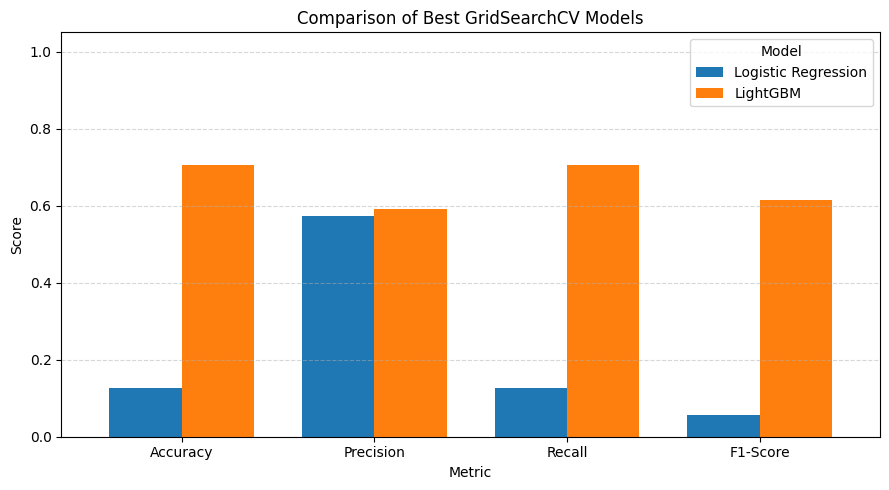

In [84]:
# Model Performance Comparison

# Performance on Predicting Test Data
y_pred_lr = best_lr.predict(X_test)
y_pred_lgbm = best_lgbm.predict(X_test)

# Evaluation metrics
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Logistic Regression": [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr, average="weighted"),
        recall_score(y_test, y_pred_lr, average="weighted"),
        f1_score(y_test, y_pred_lr, average="weighted")
    ],
    "LightGBM": [
        accuracy_score(y_test, y_pred_lgbm),
        precision_score(y_test, y_pred_lgbm, average="weighted"),
        recall_score(y_test, y_pred_lgbm, average="weighted"),
        f1_score(y_test, y_pred_lgbm, average="weighted")
    ]
})

print(results)

# Plot
ax = results.set_index("Metric").plot(
    kind="bar",
    figsize=(9,5),
    width=0.75
)

plt.title("Comparison of Best GridSearchCV Models")
plt.ylabel("Score")
plt.ylim(0,1.05)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

#### Performance Comparison of the Models Used

The evaluation metrics show that the LightGBM Classifier significantly outperformed the Logistic Regression model across most performance measures. LightGBM achieved an Accuracy of 70.53%, substantially higher than Logistic Regression's 12.59%, indicating a much better ability to correctly classify customer satisfaction levels. Similarly, LightGBM recorded a Recall of 70.53% and an F1-Score of 61.40%, whereas Logistic Regression obtained only 12.59% Recall and 5.69% F1-Score. Although the Precision values of both models were relatively close (59.25% for LightGBM and 57.42% for Logistic Regression), the overall predictive capability of LightGBM was considerably superior due to its higher Accuracy, Recall, and F1-Score. These results indicate that LightGBM is more effective at capturing the complex relationships within the customer support dataset and provides more reliable multiclass CSAT predictions. Therefore, LightGBM was selected as the final model for deployment as it offers the best balance between predictive accuracy and overall classification performance.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

The model was evaluated using Accuracy, Precision, Recall, and F1-Score to obtain a comprehensive assessment of its performance.

1. Accuracy measures the overall percentage of correctly classified customer satisfaction levels.
2. Precision evaluates how many predicted CSAT classes were actually correct, helping reduce incorrect predictions.
3. Recall measures the model's ability to correctly identify each customer satisfaction category, which is important for detecting dissatisfied customers who require immediate attention.
4. F1-Score provides a balanced measure of Precision and Recall, making it suitable for this multiclass classification problem where the class distribution is imbalanced.

Considering all four metrics ensured that the selected model achieved both high predictive performance and meaningful business value.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Among the evaluated models, the LightGBM Classifier was selected as the final prediction model. After hyperparameter tuning using GridSearchCV, it achieved the highest overall performance with approximately 70.5% Accuracy, 59.3% Precision, 70.5% Recall, and 61.4% F1-Score, outperforming Logistic Regression across all major evaluation metrics. LightGBM is also capable of capturing complex non-linear relationships within customer support data, making it more suitable for predicting customer satisfaction levels accurately.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

The final model selected for this project is the LightGBM Classifier, a gradient boosting algorithm that builds multiple decision trees sequentially to improve prediction performance while reducing classification errors.

1. LightGBM efficiently handles multiclass classification, categorical variables, and large datasets, making it well suited for customer satisfaction prediction.
2. Feature importance was analyzed using LightGBM's built-in feature importance scores, which rank features based on their contribution to the prediction process. 
3. The analysis indicated that variables such as Resolution Time, Customer Remarks, Category, Sub-category, Support Channel, Agent Shift, and Tenure Bucket were among the most influential predictors of customer satisfaction. 

These insights help the business understand which operational factors have the greatest impact on CSAT and identify areas where service improvements can lead to higher customer satisfaction.

## ***8.*** ***Future Work***

### 1. Can use Pipelines and functions to make the code efficient

A Scikit-learn Pipeline could have been used to combine preprocessing, feature transformation, SMOTE, and model training into a single workflow. This would make the code more modular, reduce redundancy, prevent data leakage, and simplify future model deployment and maintenance.

### 2. Can have best model saved and exported for deployment

The final LightGBM Classifier would be saved using the joblib library and exported for deployment. Saving the trained model enables it to be reloaded later for predicting unseen customer feedback without retraining, making the deployment process faster and more efficient.

# **Conclusion**

This project successfully developed a multiclass classification model to predict customer satisfaction levels using customer support data. After comparing Logistic Regression and LightGBM with hyperparameter tuning, the LightGBM Classifier achieved the best overall performance and was selected as the final model. The developed solution can help businesses proactively identify dissatisfied customers, improve service quality, and support data-driven decision-making for enhanced customer experience.